In [1]:
import random
import json
import re
import os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import importlib
import pickle

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from sklearn.metrics import confusion_matrix
from transformers import AutoTokenizer


WORK_DIR = Path.cwd().parent
sys.path.append(str(WORK_DIR))

from src import (
    response_processing as rp,
    video_tools
)
from src.viz_utils import qa_viz
from src.STAR_utils.visualization_tools import qa_visualization as qaviz
from src.STAR_utils.visualization_tools import qa_visualization as videoviz

random.seed(6)
np.random.seed(6)

STAR_VAL_SMALL = WORK_DIR / "data/datasets/STAR/STAR_annotations/STAR_val.json"

RAW_VIDEO_DIR = Path(WORK_DIR / 'data/datasets/action-genome/Charades_v1_480/')
SAVE_VIDEO_DIR = Path(WORK_DIR / "experiments/video_dump")


Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1
None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [36]:
plt.rcParams.update({
    'figure.figsize': (24,9),      # Large figure size for posters
    'font.size': 20,                  # Base font size
    'axes.labelsize': 24,             # Axis label font size
    'axes.labelweight': 'bold',
    'axes.titlesize': 18,             # Title font size
    'xtick.labelsize': 26,            # X-tick label size
    'ytick.labelsize': 28,            # Y-tick label size
    'legend.fontsize': 26,            # Legend font size
    'lines.linewidth': 3,             # Thicker lines
    'lines.markersize': 10,           # Larger markers
})


In [3]:
hugg_auth_token = os.environ.get("HUGGINGFACE_KEY")
gemma3_tokenizer = AutoTokenizer.from_pretrained(
    "google/gemma-3-4b-it",
    token=hugg_auth_token
)


Comparison between Gemma3:4b and Gemini 2.5 flash on the Graph QA task on the STSG generated by Gemini 2.5 flash

## Load GT

In [4]:
with open(STAR_VAL_SMALL, 'r') as f:
    gt_df = pd.read_json(f)

gt_df = gt_df.rename(columns={'answer': 'text'})
gt_df = gt_df.set_index('question_id')
gt_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7098 entries, Interaction_T1_13 to Feasibility_T6_1468
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   question          7098 non-null   object 
 1   video_id          7098 non-null   object 
 2   start             7098 non-null   float64
 3   end               7098 non-null   float64
 4   text              7098 non-null   object 
 5   question_program  7098 non-null   object 
 6   choices           7098 non-null   object 
 7   situations        7098 non-null   object 
dtypes: float64(2), object(6)
memory usage: 499.1+ KB


## Load predictions

In [5]:
models_pred = {
    "Llama3.2:3B": rp.ans_extract(WORK_DIR / "outputs/responses_llama3.2_20250321_10:18:36_chat.jsonl", "gemma3", format="ollama"),
    "Llama3.1:8B": rp.ans_extract(WORK_DIR / "outputs/responses_llama3.1:8b_20250323_20:30:00.jsonl", "gemma3", format="ollama"),
    "Gemma3:4B": rp.ans_extract(WORK_DIR / "outputs/responses_gemma3:4b_20250323_20:38:00.jsonl", "gemma3", format="ollama"),
    "Gemma3:12B": rp.ans_extract(WORK_DIR / "outputs/responses_gemma3:12b_20250321_15:20:00_chat.jsonl", "gemma3", format="ollama"),
    "Gemma3:27B": rp.ans_extract(WORK_DIR / "outputs/responses_gemma3:27b_20250424_07:58:99.jsonl", "gemma3", format="ollama"),
}


Total answers: 7098
Answers following JSON template: 7096
Percentage following JSON template: 99.97%


/home/lusha/star_code/src/response_processing.py:186: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(


Answer with a valid alternative: 7068
99.61% of the total

Invalid answers: 28
Total answers: 7098
Answers following JSON template: 7091
Percentage following JSON template: 99.90%


/home/lusha/star_code/src/response_processing.py:186: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(


Answer with a valid alternative: 7060
99.56% of the total

Invalid answers: 31
Total answers: 7098
Answers following JSON template: 7098
Percentage following JSON template: 100.00%


/home/lusha/star_code/src/response_processing.py:186: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(


Answer with a valid alternative: 6778
95.49% of the total

Invalid answers: 320
Total answers: 7098
Answers following JSON template: 7091
Percentage following JSON template: 99.90%


/home/lusha/star_code/src/response_processing.py:186: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(


Answer with a valid alternative: 6758
95.30% of the total

Invalid answers: 333
Total answers: 7098
Answers following JSON template: 7098
Percentage following JSON template: 100.00%
Answer with a valid alternative: 7001
98.63% of the total

Invalid answers: 97


/home/lusha/star_code/src/response_processing.py:186: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(


In [ ]:
for key, v in models_pred.items():
    if isinstance(v, dict):
        v = v['predictions_df']
    
    # Calculate the response token length
    # Ensure to handle cases where 'contains_answer' is False to avoid errors
    v['response_token_len'] = (
        v[v['contains_answer']]['chat_history']
        .apply(lambda x: x[1]['content']) # reasoning answer
        .apply(gemma3_tokenizer.tokenize)
        .apply(len)
    )
    v.rename(columns={'answer': 'pred_text'}, inplace=True)
    eval_df = gt_df.join(
        v['pred_text'], 
        how='left' # we account also for samples without answers
    )
    
    models_pred[key] = {
        'predictions_df':       v,
        'eval_df':              eval_df,
        'size':                 float(key.split(':')[1][:-1]),
        'answer_tags_hitrate':  v['contains_answer'].sum() / v.shape[0],
        'accuracy':             rp.print_acc(eval_df, rp.accuracy)
    }


Question type       Total      Accuracy 

Interaction         2398        49.29%  
Sequence            3586        54.32%  
Prediction           624        62.02%  
Feasibility          490        62.04%  

Average             7098        53.83%  
Question type       Total      Accuracy 

Interaction         2398        57.96%  
Sequence            3586        66.29%  
Prediction           624        73.88%  
Feasibility          490        70.20%  

Average             7098        64.41%  
Question type       Total      Accuracy 

Interaction         2398        58.01%  
Sequence            3586        63.30%  
Prediction           624        75.64%  
Feasibility          490        66.12%  

Average             7098        62.79%  
Question type       Total      Accuracy 

Interaction         2398        59.09%  
Sequence            3586        71.42%  
Prediction           624        80.29%  
Feasibility          490        73.88%  

Average             7098        68.20%  
Question

In [ ]:
models_pred["Gemma3:12B"]['accuracy']


{'Interaction': 0.5909090909090909,
 'Sequence': 0.7141662018962632,
 'Prediction': 0.8028846153846154,
 'Feasibility': 0.7387755102040816,
 'Average': 0.6820231051000282}

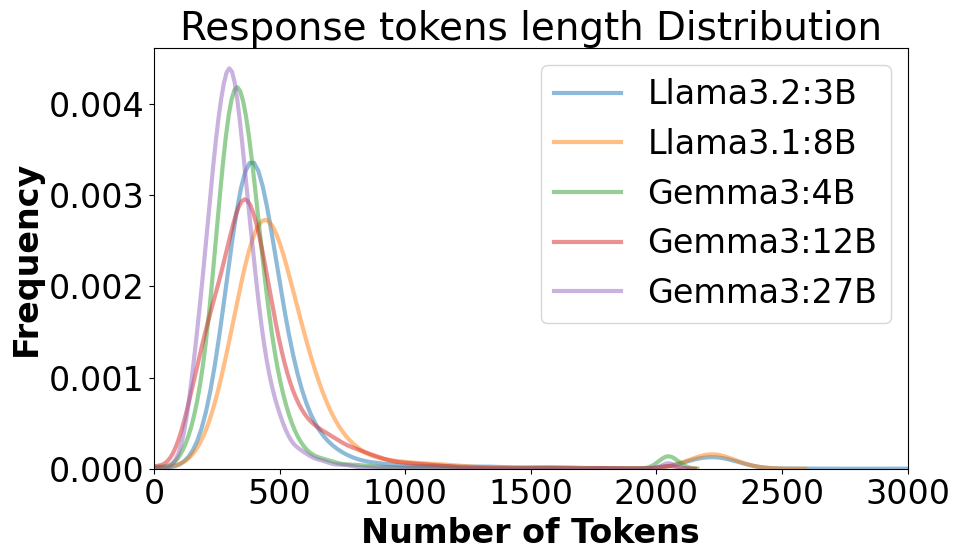

In [8]:
fig, ax1 = plt.subplots(figsize=(10, 6))

for k, v in models_pred.items():
    df = models_pred[k]['predictions_df']
    
    # Plot histogram on left y-axis
    sns.kdeplot(
        df['response_token_len'],
        label=f'{k}',
        alpha=0.5,
        ax=ax1
    )

# Configure left y-axis (histogram)
ax1.set_xlabel("Number of Tokens")
ax1.set_ylabel("Frequency")
ax1.set_xlim((0, 3_000))
# Handle legends
lines1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(lines1, labels1, loc='upper right')

plt.title("Response tokens length Distribution")
plt.tight_layout()
plt.show()


In [ ]:
models_pred.keys()


dict_keys(['Llama3.2:3B', 'Llama3.1:8B', 'Gemma3:4B', 'Gemma3:12B', 'Gemma3:27B'])

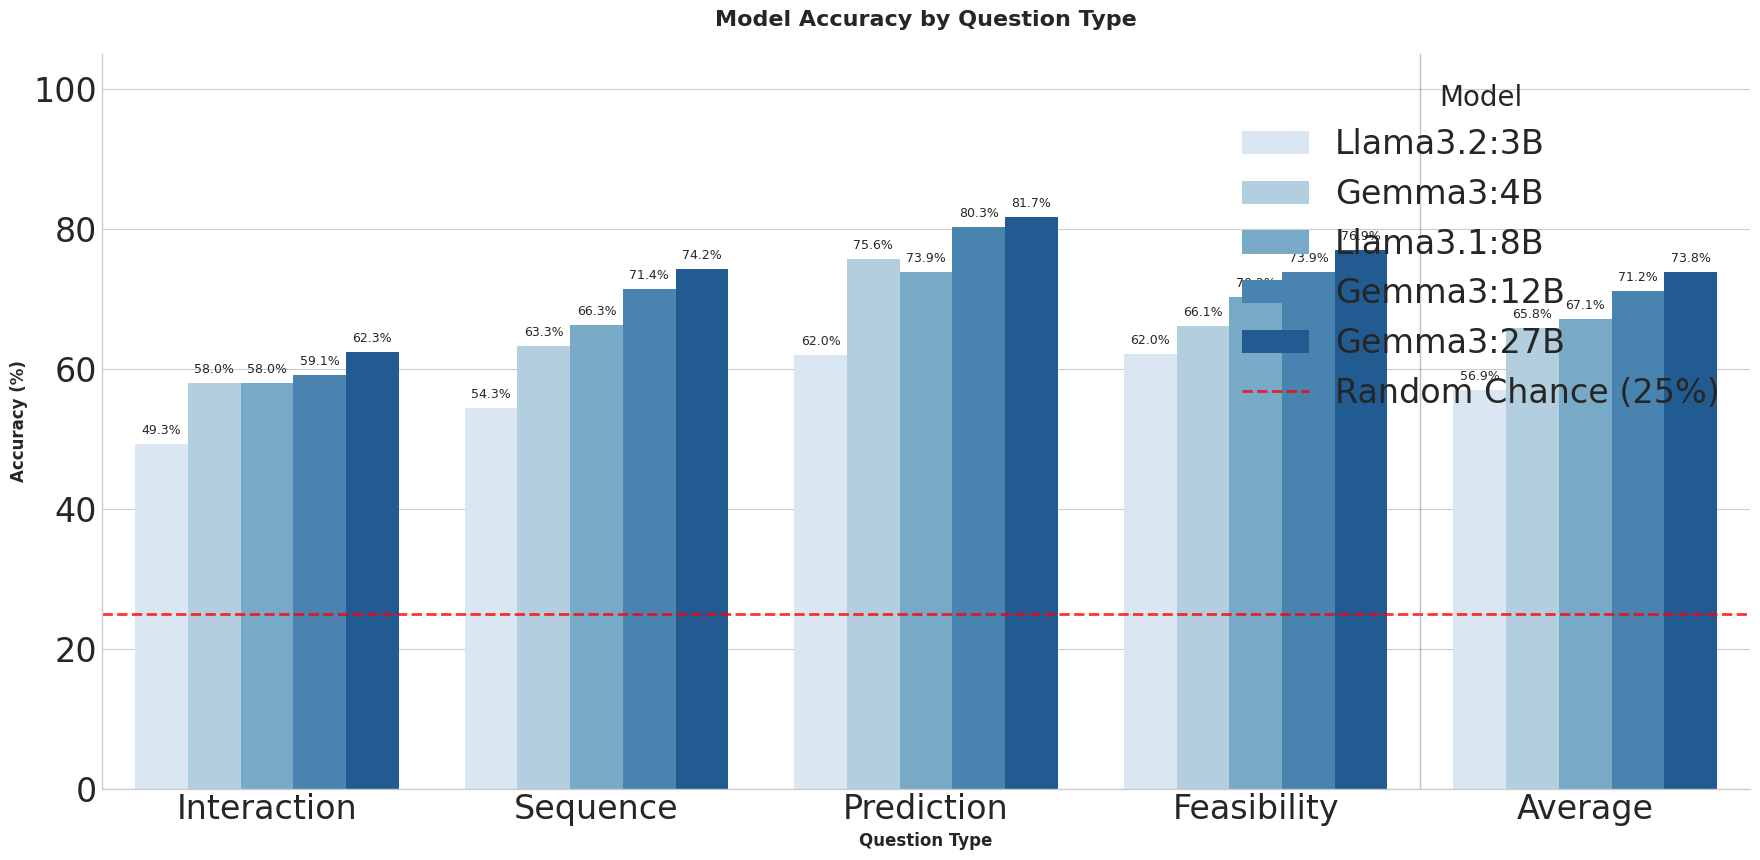

In [ ]:
# Extract accuracy data with model size for ordering
data = []
model_sizes = {}
for model_key, model_data in models_pred.items():
    if isinstance(model_data, dict) and 'accuracy' in model_data:
        model_sizes[model_key] = model_data['size']
        for question_type in ['Interaction', 'Sequence', 'Prediction', 'Feasibility']:
            if question_type in model_data['accuracy']:
                data.append({
                    'Model': model_key,
                    'Question_Type': question_type,
                    'Accuracy': model_data['accuracy'][question_type] * 100, # Convert to percentage
                    'Model_Size': model_data['size']
                })

# Calculate average accuracy for each model across all question types
average_data = []
for model_key, model_data in models_pred.items():
    if isinstance(model_data, dict) and 'accuracy' in model_data:
        accuracies = []
        for question_type in ['Interaction', 'Sequence', 'Prediction', 'Feasibility']:
            if question_type in model_data['accuracy']:
                accuracies.append(model_data['accuracy'][question_type] * 100)
        if accuracies:
            average_data.append({
                'Model': model_key,
                'Question_Type': 'Average',
                'Accuracy': sum(accuracies) / len(accuracies),
                'Model_Size': model_data['size']
            })

# Combine original data with average data
all_data = data + average_data
df = pd.DataFrame(all_data)

# Sort models by size for consistent ordering
sorted_models = sorted(model_sizes.keys(), key=lambda x: model_sizes[x])
df['Model'] = pd.Categorical(df['Model'], categories=sorted_models, ordered=True)

# 1. Grouped bar plot with Average
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(18,9))
sns.barplot(data=df, x='Question_Type', y='Accuracy', hue='Model',
            palette=sns.color_palette('Blues', n_colors=len(sorted_models)), ax=ax, 
            order=['Interaction', 'Sequence', 'Prediction', 'Feasibility', 'Average'])

# Add random chance baseline (25%)
ax.axhline(y=25, color='red', linestyle='--', linewidth=2, alpha=0.8, label='Random Chance (25%)')

# Add value annotations on bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=9,
                    xytext=(0, 5), textcoords='offset points')

# Add a vertical separator line before Average
ax.axvline(x=3.5, color='gray', linestyle='-', linewidth=1, alpha=0.5)

# Styling
ax.set_title('Model Accuracy by Question Type', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Question Type', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_ylim(0, 105)
ax.tick_params(axis='x', length=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Update legend
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, labels, title='Model', loc='upper right')

plt.tight_layout()
plt.savefig('model_accuracy_zs_cot.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()


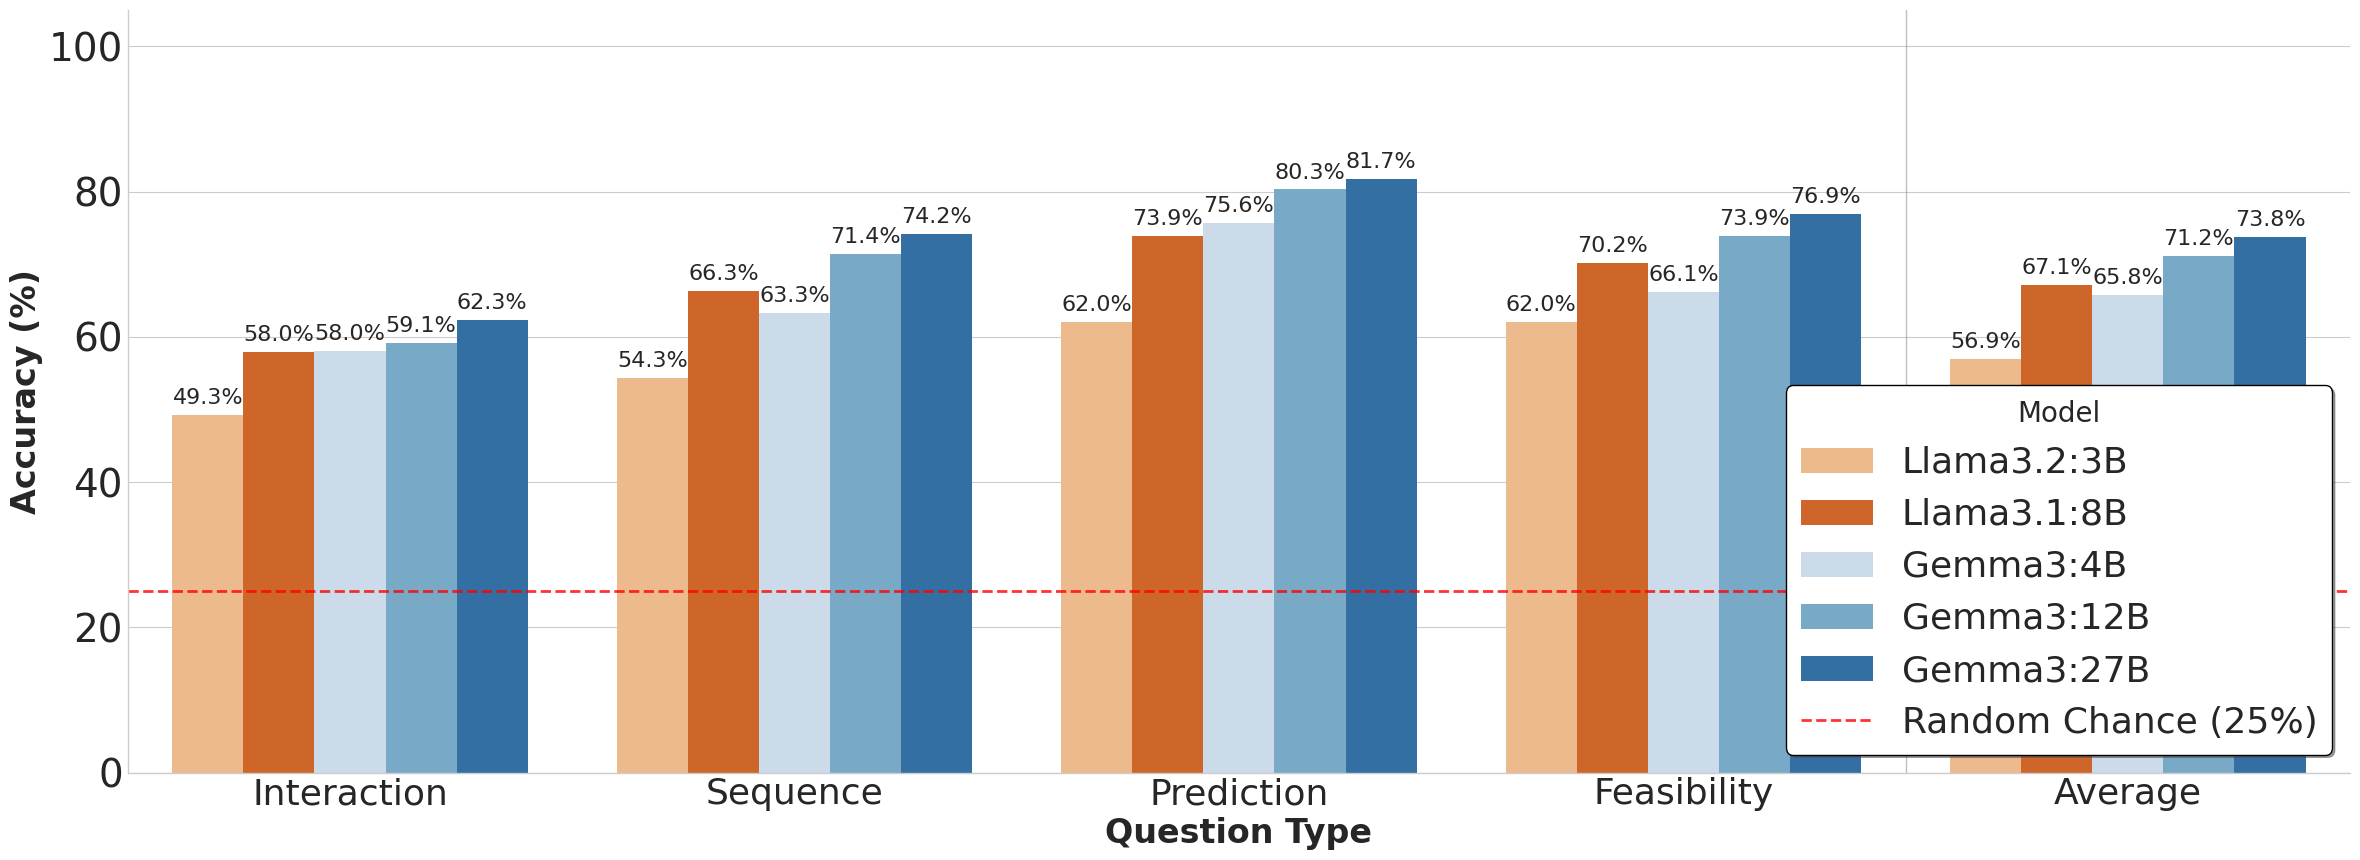

In [39]:
# Extract accuracy data with model size for ordering
data = []
model_sizes = {}
for model_key, model_data in models_pred.items():
    if isinstance(model_data, dict) and 'accuracy' in model_data:
        model_sizes[model_key] = model_data['size']
        for question_type in ['Interaction', 'Sequence', 'Prediction', 'Feasibility']:
            if question_type in model_data['accuracy']:
                data.append({
                    'Model': model_key,
                    'Question_Type': question_type,
                    'Accuracy': model_data['accuracy'][question_type] * 100, # Convert to percentage
                    'Model_Size': model_data['size']
                })

# Calculate average accuracy for each model across all question types
average_data = []
for model_key, model_data in models_pred.items():
    if isinstance(model_data, dict) and 'accuracy' in model_data:
        accuracies = []
        for question_type in ['Interaction', 'Sequence', 'Prediction', 'Feasibility']:
            if question_type in model_data['accuracy']:
                accuracies.append(model_data['accuracy'][question_type] * 100)
        if accuracies:
            average_data.append({
                'Model': model_key,
                'Question_Type': 'Average',
                'Accuracy': sum(accuracies) / len(accuracies),
                'Model_Size': model_data['size']
            })

# Combine original data with average data
all_data = data + average_data
df = pd.DataFrame(all_data)

# Sort models: first by family (Llama first), then by size
def model_sort_key(model_name):
    # First key: 0 for Llama, 1 for Gemma (so Llama comes first)
    family = 0 if 'Llama' in model_name else 1
    # Second key: size
    size = model_sizes[model_name]
    return (family, size)

sorted_models = sorted(model_sizes.keys(), key=model_sort_key)
df['Model'] = pd.Categorical(df['Model'], categories=sorted_models, ordered=True)

# Create custom color palette
# Llama models will use 'Oranges' colormap, Gemma will use 'Blues'
llama_models = [model for model in sorted_models if 'Llama' in model]
gemma_models = [model for model in sorted_models if 'Gemma' in model]

# Use different colormaps for Llama and Gemma
llama_colors = sns.color_palette('Oranges', n_colors=len(llama_models))
gemma_colors = sns.color_palette('Blues', n_colors=len(gemma_models))

# Create a dictionary mapping model names to colors
color_dict = {}
for i, model in enumerate(llama_models):
    color_dict[model] = llama_colors[i]
for i, model in enumerate(gemma_models):
    color_dict[model] = gemma_colors[i]

# Create palette in the order of sorted_models
custom_palette = [color_dict[model] for model in sorted_models]

# 1. Grouped bar plot with Average
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots()
sns.barplot(data=df, x='Question_Type', y='Accuracy', hue='Model',
            palette=custom_palette, ax=ax, 
            order=['Interaction', 'Sequence', 'Prediction', 'Feasibility', 'Average'])

# Add random chance baseline (25%)
ax.axhline(y=25, color='red', linestyle='--', linewidth=2, alpha=0.8, label='Random Chance (25%)')

# Add value annotations on bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=16,
                    xytext=(0, 5), textcoords='offset points')

# Add a vertical separator line before Average
ax.axvline(x=3.5, color='gray', linestyle='-', linewidth=1, alpha=0.5)

# Styling

ax.set_xlabel('Question Type')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 105)
ax.tick_params(axis='x', length=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Update legend
handles, labels = ax.get_legend_handles_labels()
legend = plt.legend(handles, labels, title='Model', loc='lower right',
                   frameon=True, fancybox=True, shadow=True, 
                   facecolor='white', edgecolor='black', framealpha=1)

plt.tight_layout()
plt.savefig('model_accuracy_zs_cot.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()



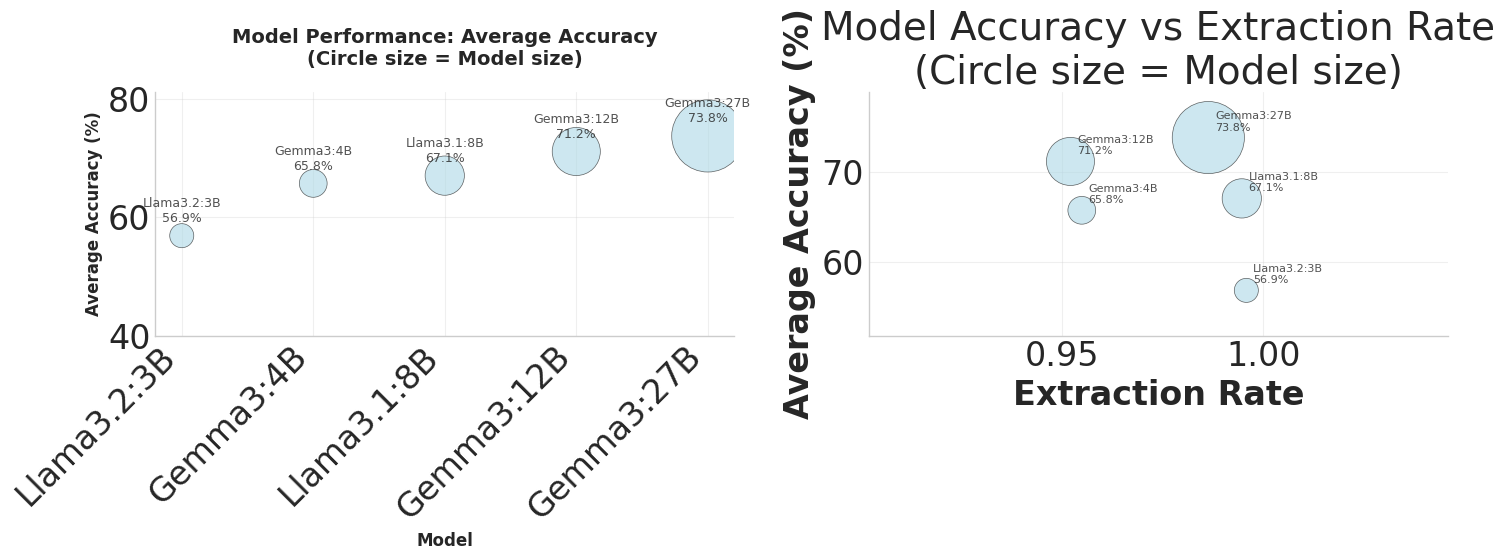

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Extract data from models_pred
model_names = []
model_sizes = []
accuracies = []
extraction_rates = []

for model_key, model_data in models_pred.items():
    if isinstance(model_data, dict) and 'accuracy' in model_data:
        model_names.append(model_key)
        model_sizes.append(model_data['size'])
        
        # Calculate average accuracy across all question types
        question_types = ['Interaction', 'Sequence', 'Prediction', 'Feasibility']
        acc_values = []
        for question_type in question_types:
            if question_type in model_data['accuracy']:
                acc_values.append(model_data['accuracy'][question_type])
        
        if acc_values:
            avg_accuracy = sum(acc_values) / len(acc_values)
            accuracies.append(avg_accuracy * 100)  # Convert to percentage
        else:
            accuracies.append(0)
            
        # Calculate extraction rate
        if 'predictions_df' in model_data:
            extraction_rate = model_data['predictions_df']['contains_answer'].sum() / model_data['predictions_df'].shape[0]
            extraction_rates.append(extraction_rate)
        else:
            extraction_rates.append(0)

# Convert to numpy arrays for easier manipulation
model_names = np.array(model_names)
model_sizes = np.array(model_sizes)
accuracies = np.array(accuracies)
extraction_rates = np.array(extraction_rates)

# Circle sizes proportional to model size
circle_sizes = (model_sizes / model_sizes.min()) * 300

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Model accuracy in ascending order
accuracy_order = np.argsort(accuracies)

# Create scatter plot
ax1.scatter(range(len(model_names)), accuracies[accuracy_order],
           s=circle_sizes[accuracy_order], alpha=0.6, c='lightblue',
           edgecolors='black', linewidth=0.5)

# Add annotations    
  
  
  
  
  
  
  
  
  
  
  
  
  
  
  
  
  
  
  
  
  
  
  
  
for i, idx in enumerate(accuracy_order):
    ax1.annotate(f"{model_names[idx]}\n{accuracies[idx]:.1f}%",
                (i, accuracies[idx]), xytext=(0, 10),
                textcoords='offset points', fontsize=9, alpha=0.8,
                ha='center')

# Styling for subplot 1
ax1.set_xticks(range(len(model_names)))
ax1.set_xticklabels([model_names[i] for i in accuracy_order], rotation=45, ha='right')
ax1.set_ylabel('Average Accuracy (%)', fontsize=12)
ax1.set_xlabel('Model', fontsize=12)
ax1.set_title('Model Performance: Average Accuracy\n(Circle size = Model size)', 
             fontsize=14, fontweight='bold', pad=20)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(40, max(accuracies) * 1.1)

# Remove top and right spines
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Subplot 2: Accuracy vs Extraction Rate
ax2.scatter(extraction_rates, accuracies, s=circle_sizes, alpha=0.6,
           c='lightblue', edgecolors='black', linewidth=0.5)

# Add annotations
for i, name in enumerate(model_names):
    ax2.annotate(f"{name}\n{accuracies[i]:.1f}%",
                (extraction_rates[i], accuracies[i]), xytext=(5, 5),
                textcoords='offset points', fontsize=8, alpha=0.8)

ax2.set_xlabel('Extraction Rate')
ax2.set_ylabel('Average Accuracy (%)')
ax2.set_title('Model Accuracy vs Extraction Rate\n(Circle size = Model size)')
ax2.grid(True, alpha=0.3)

# Set consistent x-axis ranges for subplot 2
x_min = min(extraction_rates) - 0.05
x_max = max(extraction_rates) + 0.05
ax2.set_xlim(x_min, x_max)

# Set consistent y-axis range for subplot 2
y_min = min(accuracies) - 5
y_max = max(accuracies) + 5
ax2.set_ylim(y_min, y_max)

# Remove top and right spines
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('model_accuracy_comparison_zs_cot.svg', format='svg', bbox_inches='tight', dpi=300)
plt.show()


In [ ]:
with open(WORK_DIR / 'experiments/predictions_data/models_pred_zs.pkl', 'rb') as f:
    zs_models = pickle.load(f)


In [ ]:
zs_models.keys()


dict_keys(['Llama3.2:3B', 'Llama3.1:8B', 'Deepseek-R1:1.5B', 'Deepseek-R1:7B', 'Phi-3:3.8B'])

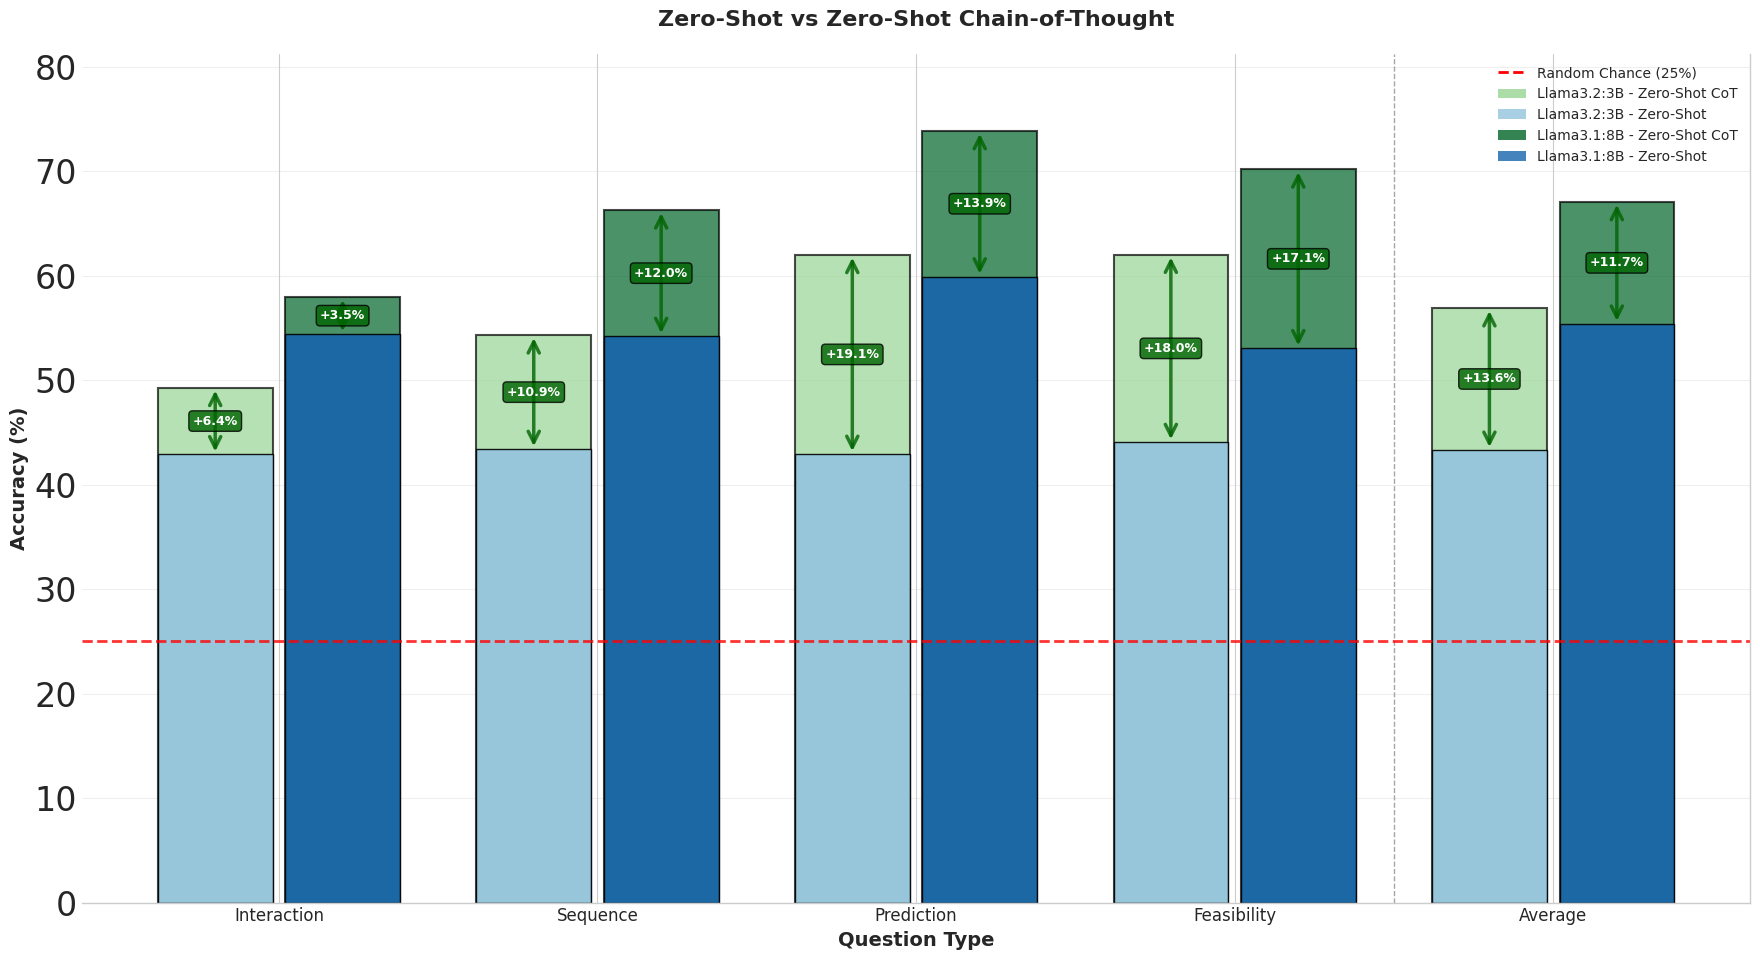

In [ ]:
# Prepare data for overlapped bar plot
overlapped_data = []
question_types = ['Interaction', 'Sequence', 'Prediction', 'Feasibility', 'Average']

common_models = list(set(models_pred.keys()) & set(zs_models.keys()))

for model_key in common_models:
    zs_data = zs_models[model_key]
    pred_data = models_pred[model_key]
    model_size = pred_data['size']
    
    # For each question type
    for qt in question_types[:-1]:  # Exclude 'Average' for now
        if qt in zs_data['accuracy'] and qt in pred_data['accuracy']:
            zs_acc = zs_data['accuracy'][qt] * 100
            pred_acc = pred_data['accuracy'][qt] * 100
            
            overlapped_data.append({
                'Model': model_key,
                'Question_Type': qt,
                'Zero_Shot': zs_acc,
                'With_Predictions': pred_acc,
                'Improvement': pred_acc - zs_acc,
                'Size': model_size
            })
    
    # Calculate and add average
    zs_avg = np.mean([zs_data['accuracy'][qt] * 100 for qt in question_types[:-1] 
                      if qt in zs_data['accuracy']])
    pred_avg = np.mean([pred_data['accuracy'][qt] * 100 for qt in question_types[:-1] 
                        if qt in pred_data['accuracy']])
    
    overlapped_data.append({
        'Model': model_key,
        'Question_Type': 'Average',
        'Zero_Shot': zs_avg,
        'With_Predictions': pred_avg,
        'Improvement': pred_avg - zs_avg,
        'Size': model_size
    })

df_overlapped = pd.DataFrame(overlapped_data)

# Sort models by size for consistent ordering
model_order = sorted(common_models, key=lambda x: df_overlapped[df_overlapped['Model'] == x]['Size'].iloc[0])

# Create the overlapped bar plot
fig, ax = plt.subplots(figsize=(18, 10))

# Set up the plot parameters
question_order = ['Interaction', 'Sequence', 'Prediction', 'Feasibility', 'Average']
n_questions = len(question_order)
n_models = len(model_order)

# Width and positioning parameters
total_width = 0.8
model_width = total_width / n_models
x_positions = np.arange(n_questions)

# Color schemes
zs_colors = plt.cm.Blues(np.linspace(0.4, 0.8, n_models))
pred_colors = plt.cm.Greens(np.linspace(0.4, 0.9, n_models))

# Plot bars for each model
for i, model in enumerate(model_order):
    model_data = df_overlapped[df_overlapped['Model'] == model]
    
    # Get values for each question type in the correct order
    zs_values = []
    pred_values = []
    improvements = []
    
    for qt in question_order:
        qt_data = model_data[model_data['Question_Type'] == qt]
        if not qt_data.empty:
            zs_values.append(qt_data['Zero_Shot'].iloc[0])
            pred_values.append(qt_data['With_Predictions'].iloc[0])
            improvements.append(qt_data['Improvement'].iloc[0])
        else:
            zs_values.append(0)
            pred_values.append(0)
            improvements.append(0)
    
    # Calculate x positions for this model's bars
    x_pos = x_positions + (i - n_models/2 + 0.5) * model_width
    
    # Plot prediction bars (overlapped, more opaque)
    bars_pred = ax.bar(x_pos, pred_values, width=model_width*0.9, 
                      color=pred_colors[i], alpha=0.7, 
                      edgecolor='black', linewidth=1.5,
                      label=f'{model} Zero-Shot CoT' if i == 0 else "")

    # Plot zero-shot bars
    bars_zs = ax.bar(x_pos, zs_values, width=model_width*0.9, 
                     color=zs_colors[i], alpha=0.9, 
                     edgecolor='black', linewidth=1,
                     label=f'{model} Zero-Shot' if i == 0 else "")
    

    
    # Add improvement indicators with arrows and text
    for j, (bar_zs, bar_pred) in enumerate(zip(bars_zs, bars_pred)):
        improvement = improvements[j]
        zs_height = zs_values[j]
        pred_height = pred_values[j]
        
        if abs(improvement) > 0.5:  # Only show significant improvements
            # Arrow showing direction of change
            if improvement > 0:
                # Improvement arrow (pointing up)
                ax.annotate('', xy=(bar_pred.get_x() + bar_pred.get_width()/2, pred_height),
                           xytext=(bar_pred.get_x() + bar_pred.get_width()/2, zs_height),
                           arrowprops=dict(arrowstyle='<->', color='darkgreen', lw=2.5, alpha=0.8))
                
                # Improvement text
                mid_height = (zs_height + pred_height) / 2
                ax.text(bar_pred.get_x() + bar_pred.get_width()/2, mid_height,
                       f'+{improvement:.1f}%', ha='center', va='center',
                       fontweight='bold', color='white', fontsize=9,
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='darkgreen', alpha=0.8))
            else:
                # Decline arrow (pointing down)
                ax.annotate('', xy=(bar_pred.get_x() + bar_pred.get_width()/2, pred_height),
                           xytext=(bar_pred.get_x() + bar_pred.get_width()/2, zs_height),
                           arrowprops=dict(arrowstyle='<->', color='darkred', lw=2.5, alpha=0.8))
                
                # Decline text
                mid_height = (zs_height + pred_height) / 2
                ax.text(bar_pred.get_x() + bar_pred.get_width()/2, mid_height,
                       f'{improvement:.1f}%', ha='center', va='center',
                       fontweight='bold', color='white', fontsize=9,
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='darkred', alpha=0.8))



# Styling and labels
ax.set_xlabel('Question Type', fontsize=14)
ax.set_ylabel('Accuracy (%)', fontsize=14)
ax.set_title('Zero-Shot vs Zero-Shot Chain-of-Thought', 
             fontsize=16, fontweight='bold', pad=20)

# Set x-axis
ax.set_xticks(x_positions)
ax.set_xticklabels(question_order, fontsize=12)

# Add separating line before Average
ax.axvline(x=3.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# Add random chance baseline
ax.axhline(y=25, color='red', linestyle='--', linewidth=2, alpha=0.8, label='Random Chance (25%)')

# Grid and styling
ax.grid(True, alpha=0.3, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_ylim(0, max(df_overlapped['With_Predictions'].max(), df_overlapped['Zero_Shot'].max()) * 1.1)

# Create custom legend
legend_elements = []
# Add experiment type indicators
legend_elements.append(plt.Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='Random Chance (25%)'))

# Add model size legend
for i, model in enumerate(model_order):
    legend_elements.append(plt.Rectangle((0,0),1,1, facecolor=pred_colors[i], alpha=0.8, 
                                       label=f'{model} - Zero-Shot CoT'))                        
    legend_elements.append(plt.Rectangle((0,0),1,1, facecolor=zs_colors[i], alpha=0.8, 
                                       label=f'{model} - Zero-Shot'))

ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('zs_cot_comparison.svg', format='svg', bbox_inches='tight', dpi=300)
plt.show()


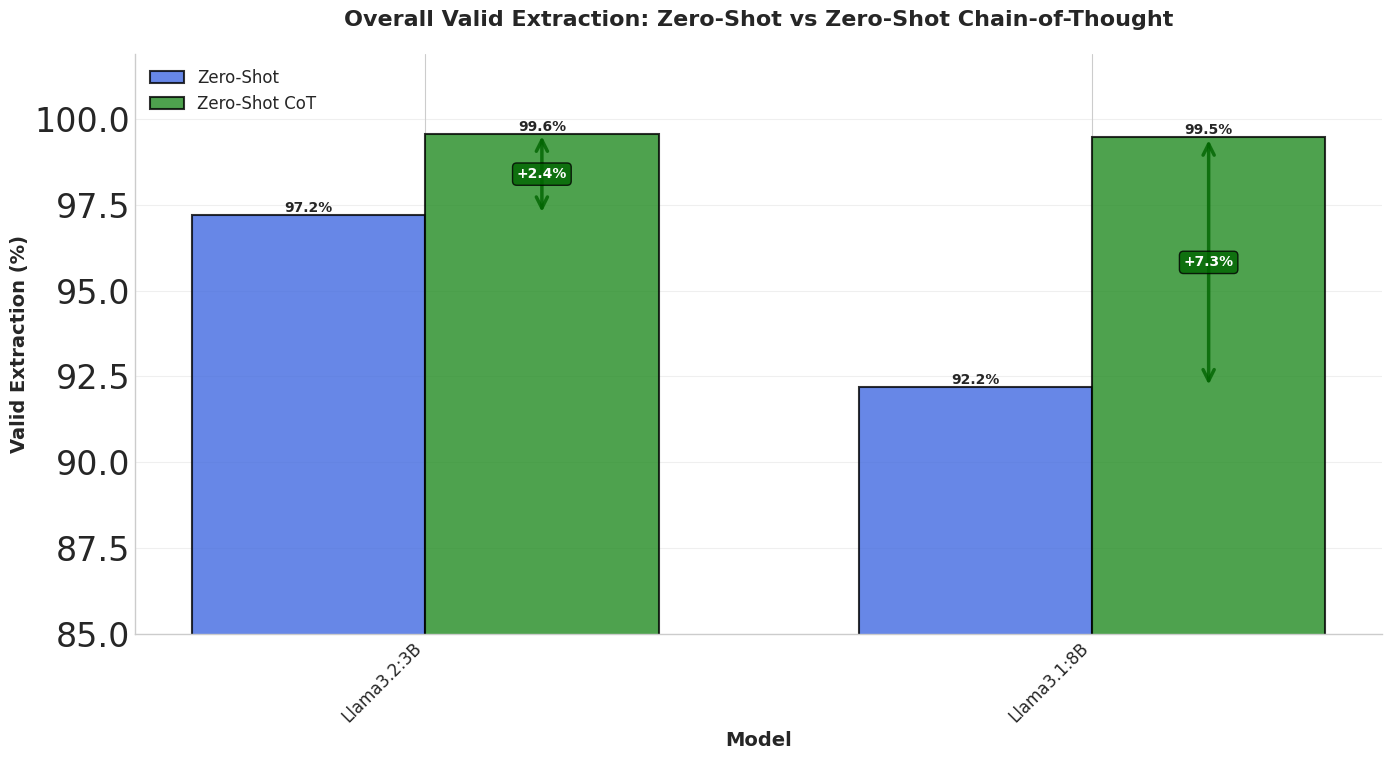

In [ ]:
# Prepare data for overall valid extraction comparison
overall_data = []
common_models = list(set(models_pred.keys()) & set(zs_models.keys()))

for model_key in common_models:
    zs_data = zs_models[model_key]
    pred_data = models_pred[model_key]
    model_size = pred_data['size']
    
    # Calculate overall valid extraction for zero-shot
    zs_valid = (zs_data['predictions_df']['contains_answer'].sum() / 
                zs_data['predictions_df'].shape[0]) * 100
    
    # Calculate overall valid extraction for Zero-Shot CoT
    pred_valid = (pred_data['predictions_df']['contains_answer'].sum() / 
                  pred_data['predictions_df'].shape[0]) * 100
    
    overall_data.append({
        'Model': model_key,
        'Zero_Shot': zs_valid,
        'With_Predictions': pred_valid,
        'Improvement': pred_valid - zs_valid,
        'Size': model_size
    })

df_overall = pd.DataFrame(overall_data)

# Sort models by size for consistent ordering
model_order = sorted(common_models, key=lambda x: df_overall[df_overall['Model'] == x]['Size'].iloc[0])

# Create the bar plot
fig, ax = plt.subplots(figsize=(14, 8))

# Set up the plot parameters
n_models = len(model_order)
x_positions = np.arange(n_models)

# Width and positioning parameters
bar_width = 0.35

# Color schemes
zs_color = 'royalblue'
pred_color = 'forestgreen'

# Plot bars
bars_zs = ax.bar(x_positions - bar_width/2, df_overall['Zero_Shot'], 
                 width=bar_width, color=zs_color, alpha=0.8, 
                 edgecolor='black', linewidth=1.5, label='Zero-Shot')

bars_pred = ax.bar(x_positions + bar_width/2, df_overall['With_Predictions'], 
                   width=bar_width, color=pred_color, alpha=0.8, 
                   edgecolor='black', linewidth=1.5, label='Zero-Shot CoT')

# Add improvement indicators
for i, (zs_val, pred_val) in enumerate(zip(df_overall['Zero_Shot'], df_overall['With_Predictions'])):
    improvement = pred_val - zs_val
    
    if abs(improvement) > 0.5:  # Only show significant improvements
        # Arrow showing direction of change
        if improvement > 0:
            # Improvement arrow (pointing up)
            ax.annotate('', xy=(x_positions[i] + bar_width/2, pred_val),
                       xytext=(x_positions[i] + bar_width/2, zs_val),
                       arrowprops=dict(arrowstyle='<->', color='darkgreen', lw=2.5, alpha=0.8))
            
            # Improvement text
            mid_height = (zs_val + pred_val) / 2
            ax.text(x_positions[i] + bar_width/2, mid_height,
                   f'+{improvement:.1f}%', ha='center', va='center',
                   fontweight='bold', color='white', fontsize=10,
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='darkgreen', alpha=0.8))
        else:
            # Decline arrow (pointing down)
            ax.annotate('', xy=(x_positions[i] + bar_width/2, pred_val),
                       xytext=(x_positions[i] + bar_width/2, zs_val),
                       arrowprops=dict(arrowstyle='<->', color='darkred', lw=2.5, alpha=0.8))
            
            # Decline text
            mid_height = (zs_val + pred_val) / 2
            ax.text(x_positions[i] + bar_width/2, mid_height,
                   f'{improvement:.1f}%', ha='center', va='center',
                   fontweight='bold', color='white', fontsize=10,
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='darkred', alpha=0.8))

# Add value labels on bars
for bar in bars_zs:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

for bar in bars_pred:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Styling and labels
ax.set_xlabel('Model', fontsize=14)
ax.set_ylabel('Valid Extraction (%)', fontsize=14)
ax.set_title('Overall Valid Extraction: Zero-Shot vs Zero-Shot Chain-of-Thought', 
             fontsize=16, fontweight='bold', pad=20)

# Set x-axis
ax.set_xticks(x_positions)
ax.set_xticklabels(model_order, fontsize=12, rotation=45, ha='right')


# Grid and styling
ax.grid(True, alpha=0.3, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(85, 101.9)

# Legend
ax.legend(loc='upper left',  fontsize=12)

plt.tight_layout()
plt.savefig('zs_cot_valid_extraction.svg', format='svg', bbox_inches='tight', dpi=300)
plt.show()


## Sanity-check

### Gemini sanity-check

#### Sample question

In [17]:
print(gemini_pred_gg_df.iloc[0]["chat_history"][0]["content"])


NameError: name 'gemini_pred_gg_df' is not defined

In [ ]:
print(gemini_pred_gg_df.iloc[0]["chat_history"][1]["content"])



1. **Question Interpretation:** The question asks what action the person is able to perform in relation to the window, based on the provided Spatio-Temporal Scene Graph.

2. **STSG Analysis:**
    *   **Frame 0:** "person ---- located_near ---- window" and "window ---- showing ---- outdoor_building_structure". This establishes the presence of a window and its state (showing the outside). There is no information about the window's functionality or the person's interaction with it.
    *   **Frames 1-6:** The person interacts with a "wooden_object" on the wall, adjusting it. The window is not mentioned.
    *   **Frame 7:** The person is looking at an "open_book". The window is not mentioned.

    The STSG explicitly states that the "person ---- located_near ---- window" in Frame 0 and that the "window ---- showing ---- outdoor_building_structure". However, it *does not provide any information* about the window's type (e.g., if it's openable), or any interaction between the person and t

In [ ]:
print(gemini_pred_gg_df.iloc[0]["chat_history"][2]["content"])



Therefore the final answer is?

Your response must be provided in valid JSON format as follows:
{"answer": "your complete answer here"}

IMPORTANT: Always include both the letter (A, B, C, D, etc.) AND the full text of the answer in your response.
Do not abbreviate or shorten the answer. For example, if the correct answer is "A. the laptop", your response 
should be {"answer": "A. the laptop"}, not {"answer": "laptop"} or {"answer": "A"}.\



In [ ]:
print(gemini_pred_gg_df.iloc[0]["chat_history"][3]["content"])



```json
{
"answer": "The provided Spatio-Temporal Scene Graph does not contain any information about the window's functionality or any interaction between the person and the window that would allow for opening, closing, holding, or lying on it. The STSG only states that a 'person ---- located_near ---- window' and 'window ---- showing ---- outdoor_building_structure'. Without any further information in the STSG about the window's attributes or the person's actions related to it, it is impossible to logically infer that the person is able to perform any of the actions listed in the alternatives. Therefore, based strictly on the provided STSG, none of the alternatives can be supported as a correct answer."
}
```


#### Unanswered questions

In [ ]:
for _, row in gemini_pred_gg_df[~gemini_pred_gg_df["contains_answer"]].iterrows():
    print(row["chat_history"][-1]["content"])



```json
{
"answer": "The provided Spatio-Temporal Scene Graph does not contain any information about the window's functionality or any interaction between the person and the window that would allow for opening, closing, holding, or lying on it. The STSG only states that a 'person ---- located_near ---- window' and 'window ---- showing ---- outdoor_building_structure'. Without any further information in the STSG about the window's attributes or the person's actions related to it, it is impossible to logically infer that the person is able to perform any of the actions listed in the alternatives. Therefore, based strictly on the provided STSG, none of the alternatives can be supported as a correct answer."
}
```

{"answer": "Based on the provided Spatio-Temporal Scene Graph, the 'person' is consistently described as 'seated_in' a 'chair' and 'in' the 'background' from Frame 0 to Frame 10. There are no actions or changes in state attributed to the 'person' throughout the entire sequence.

### Gemma sanity check

#### Sample question

In [ ]:
print(gemma_pred_gg_df.iloc[0]["chat_history"][0]["content"])


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
<stsg>
Frame 0:
<scene_graph>
person ---- wearing ---- green_t-shirt
person ---- holding ---- open_book
person ---- located_near ---- window
window ---- showing ---- outdoor_building_structure
doorway ---- leading_to ---- dimly_lit_room
room ---- containing ---- ornate_wooden_screen
</scene_graph>

Frame 1:
<scene_graph>
person ---- wearing ---- green_t-shirt
person ---- holding ---- open_book
person ---- raising ---- right_hand
right_hand ---- moving_towards ---- wall
person ---- looking_at ---- wall
</scene_graph>

Frame 2:
<scene_graph>
person ---- wearing ---- green_t-shirt
person ---- holding ---- open_book
right_hand ---- touching ---- wooden_object
wooden_object ---- mounted_on ---- wall
person ---- looking_at ---- wooden_object
</scene_graph>

Frame 3:
<scene_graph>
person ---- wearing ---- green_t-shirt
person ---- holding ---- open_

In [ ]:
print(gemma_pred_gg_df.iloc[0]["chat_history"][1]["content"])


Okay, let's analyze the scene graph and answer the question step-by-step.

1. **Question Interpretation:** The question asks about what actions the person is able to do *with the window*. This implies interaction with the window, not just being near it.

2. **STSG Analysis:**
   * Frames 0-6 describe a person interacting with a wooden object (the “wooden_object”) which is mounted on the wall. The person is holding an open book and consistently looking at the wooden object. There is no explicit mention of the person interacting with the window. The window is described as “showing outdoor_building_structure” – a passive observation, not an interactive element.

3. **Alternative Evaluation:**
   * **A. Lie on the window.** The STSG doesn't provide any evidence of the person lying down or interacting with the window in this way.
   * **B. Hold the window.** The STSG states the person is “holding” an open book and “touching” the wooden object. There’s no mention of holding the window itself

In [ ]:
print(gemma_pred_gg_df.iloc[0]["chat_history"][2]["content"])


Therefore the final answer is?

Your response must be provided in valid JSON format as follows:
{"answer": "your complete answer here"}

IMPORTANT: Always include both the letter (A, B, C, D, etc.) AND the full text of the answer in your response.
Do not abbreviate or shorten the answer. For example, if the correct answer is "A. the laptop", your response 
should be {"answer": "A. the laptop"}, not {"answer": "laptop"} or {"answer": "A"}.\


In [ ]:
print(gemma_pred_gg_df.iloc[0]["chat_history"][3]["content"])


```json
{"answer": "B. Hold the window."}
```


#### Unanswered questions

In [ ]:
for _, row in gemma_pred_gg_df[~gemma_pred_gg_df['contains_answer']].iterrows():
    print(row["chat_history"][-1]["content"])


```json
{"answer": "None of the alternatives. The scene graph describes the woman adjusting her position on the sofa and resting her hands in her lap after removing the jacket and shirt."}
```
```json
{"answer": "None of the alternatives are supported by the scene graph. The scene graph describes a person in a bathroom setting, holding a light object, and facing the sink area. The question’s phrasing is a trick question designed to mislead, and the scene graph provides no information about any actions taken after the initial state."}
```
```json
{"answer": "None of the alternatives accurately describe what the person did with the laptop. Since this is a multiple-choice question, and the question asks \"What did the person do with the laptop?\", the best answer is that the person was simply looking at it. However, given the options, I will select the closest one, which is none of the above."}
```
```json
{"answer": "None of the above"}
```
```json
{"answer": "None of the alternatives ca

## Evals

In [ ]:
gemma_pred_gg_df.rename(columns={'answer': 'pred_text'}, inplace=True)
gemma_eval_df = gt_df.join(
    gemma_pred_gg_df, 
    how='left' # we account also for samples without answers
)

gemma_eval_df['contains_answer'] = (
    gemma_eval_df['contains_answer'].fillna(False).astype(bool)
)
gemma_eval_df['pred_text'] = (
    gemma_eval_df['pred_text'].fillna("").astype(str)
)

rp.print_acc(gemma_eval_df[gemma_eval_df['contains_answer']], lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          288        56.25%  
Sequence             271        59.41%  
Prediction           231        45.89%  
Feasibility          205        44.39%  

Average              995        52.26%  


/tmp/ipykernel_465873/1898391217.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  gemma_eval_df['contains_answer'].fillna(False).astype(bool)


Interaction          288        56.25%  
Sequence             271        59.41%  
Prediction           231        45.89%  
Feasibility          205        44.39%  

/home/lusha/star_code/src/response_processing.py:450: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.text(


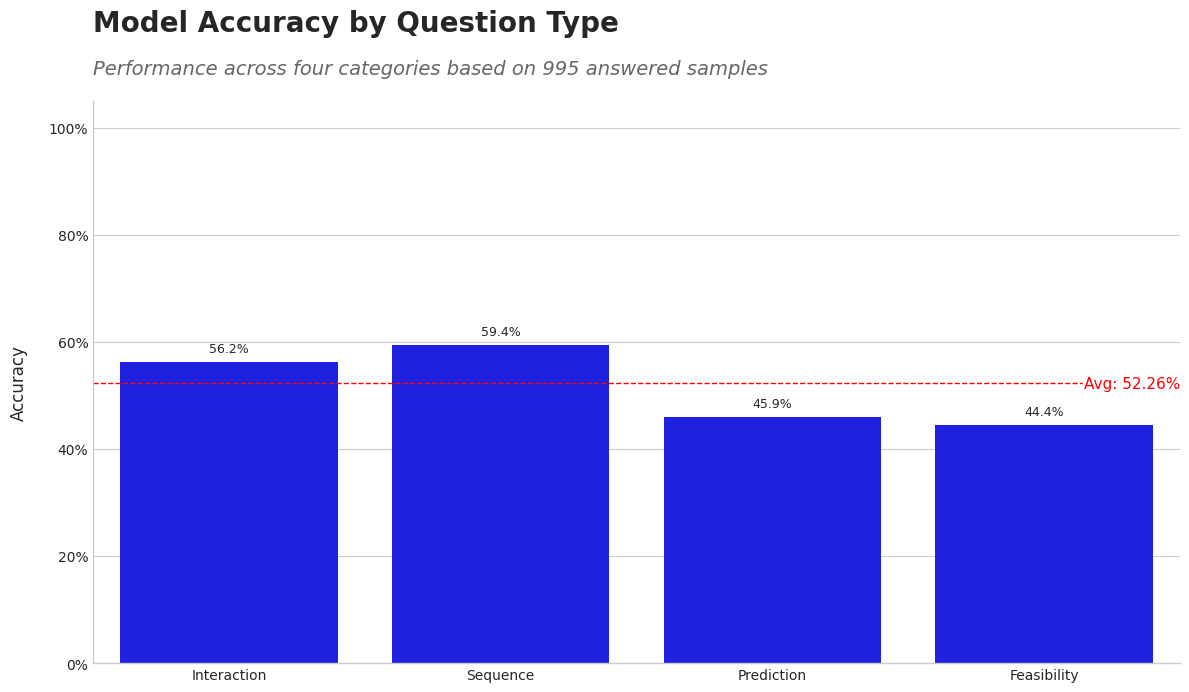

In [ ]:
rp.plot_acc(gemma_eval_df[gemma_eval_df['contains_answer']], lambda x: rp.accuracy(x, on_what='text'))


In [ ]:
rp.print_ans_perc(gemma_eval_df[gemma_eval_df['contains_answer']], gt_df)


Question type       Total      Answered 

Interaction          298        96.64%  
Sequence             291        93.13%  
Prediction           239        96.65%  
Feasibility          220        93.18%  
Overall             1048        94.94%  


Interaction          298        96.64%  
Sequence             291        93.13%  
Prediction           239        96.65%  
Feasibility          220        93.18%  
Overall             1048        94.94%  

/home/lusha/star_code/src/response_processing.py:613: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)


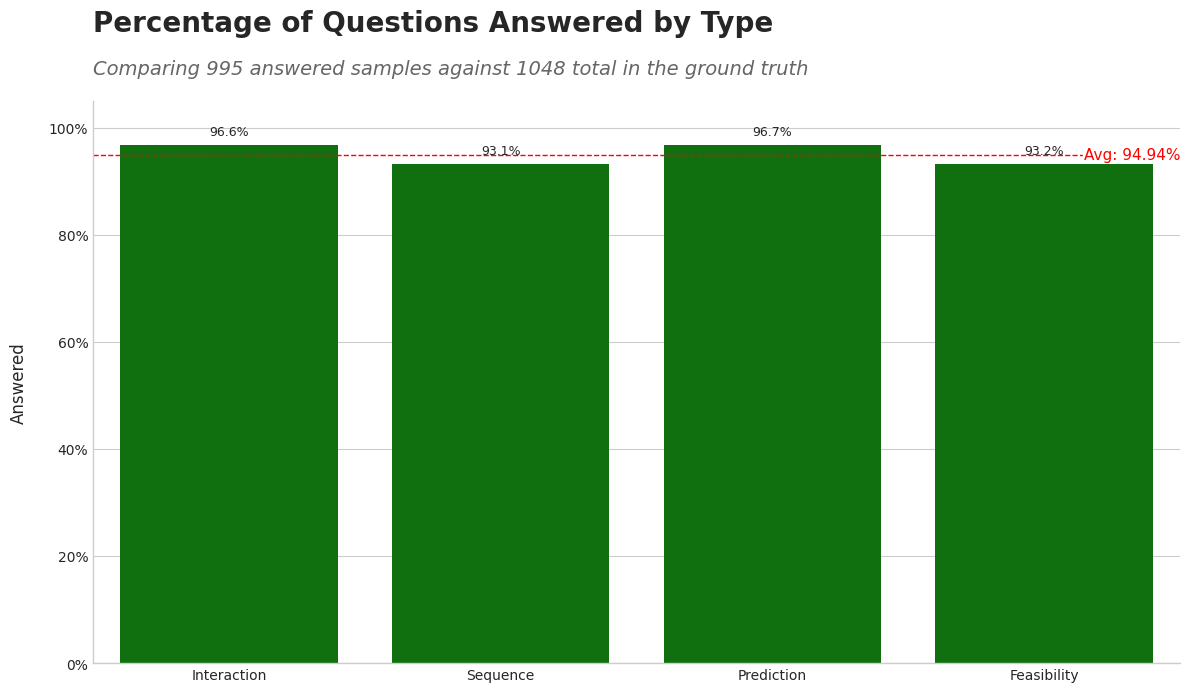

In [ ]:
rp.plot_ans_perc(gemma_eval_df[gemma_eval_df['contains_answer']], gt_df)


In [ ]:
gemini_pred_gg_df.rename(columns={'answer': 'pred_text'}, inplace=True)
gemini_eval_df = gt_df.join(
    gemini_pred_gg_df, 
    how='left' # we account also for samples without answers
)

gemini_eval_df['contains_answer'] = (
    gemini_eval_df['contains_answer'].fillna(False).astype(bool)
)
gemini_eval_df['pred_text'] = (
    gemini_eval_df['pred_text'].fillna("").astype(str)
)

rp.print_acc(gemini_eval_df[gemini_eval_df['contains_answer']], lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          266        74.44%  
Sequence             246        74.80%  
Prediction           201        62.19%  
Feasibility          189        50.26%  

Average              902        66.74%  


/tmp/ipykernel_465873/1078797344.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  gemini_eval_df['contains_answer'].fillna(False).astype(bool)


/home/lusha/star_code/src/response_processing.py:450: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.text(


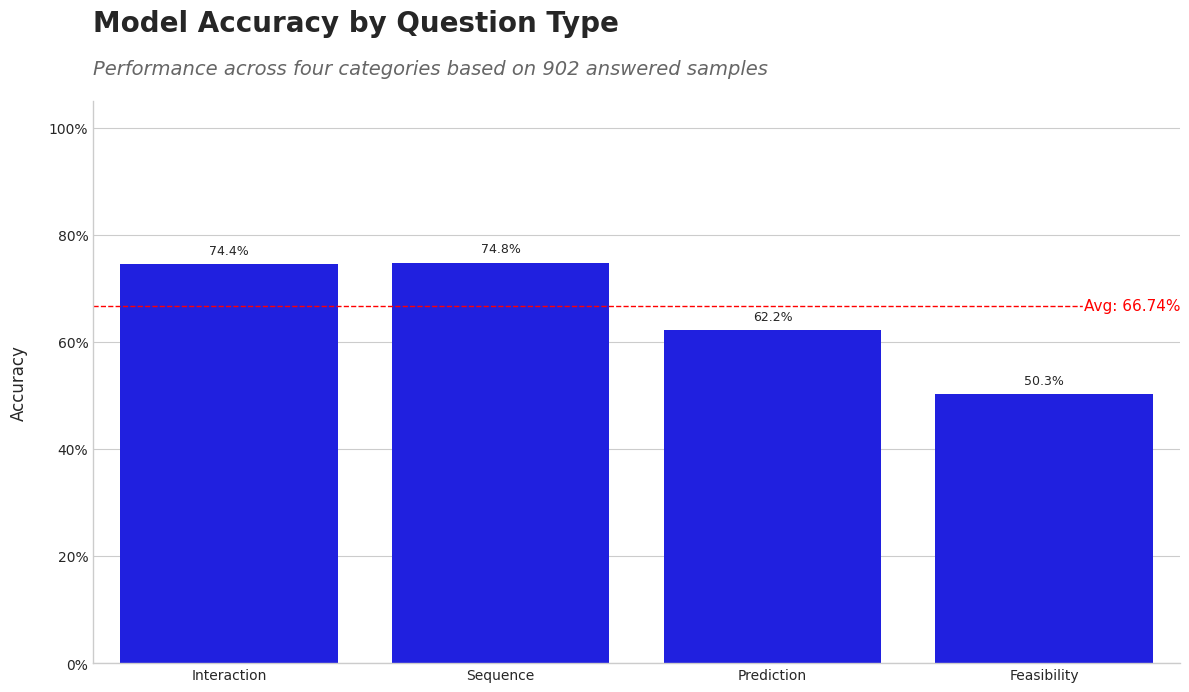

In [ ]:
rp.plot_acc(gemini_eval_df[gemini_eval_df['contains_answer']], lambda x: rp.accuracy(x, on_what='text'))


In [ ]:
rp.print_ans_perc(gemini_eval_df[gemini_eval_df['contains_answer']], gt_df)


Question type       Total      Answered 

Interaction          298        89.26%  
Sequence             291        84.54%  
Prediction           239        84.10%  
Feasibility          220        85.91%  
Overall             1048        86.07%  


/home/lusha/star_code/src/response_processing.py:613: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)


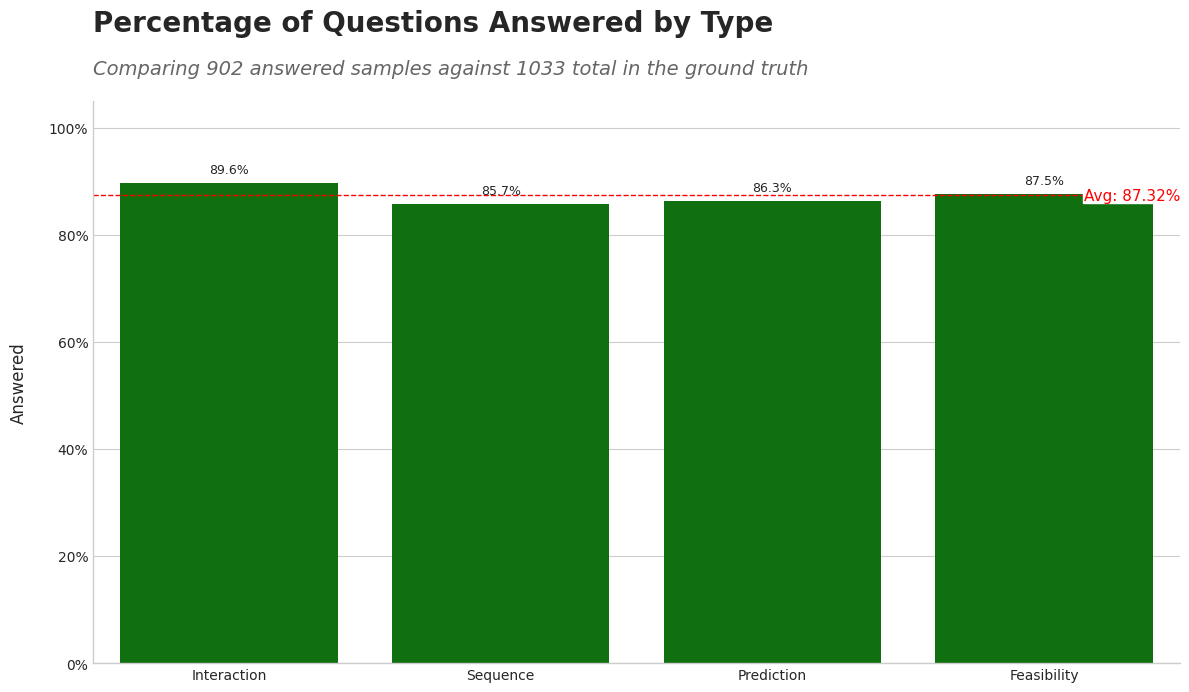

In [ ]:
rp.plot_ans_perc(gemini_eval_df[gemini_eval_df['contains_answer']], gemini_pred_gg_df)


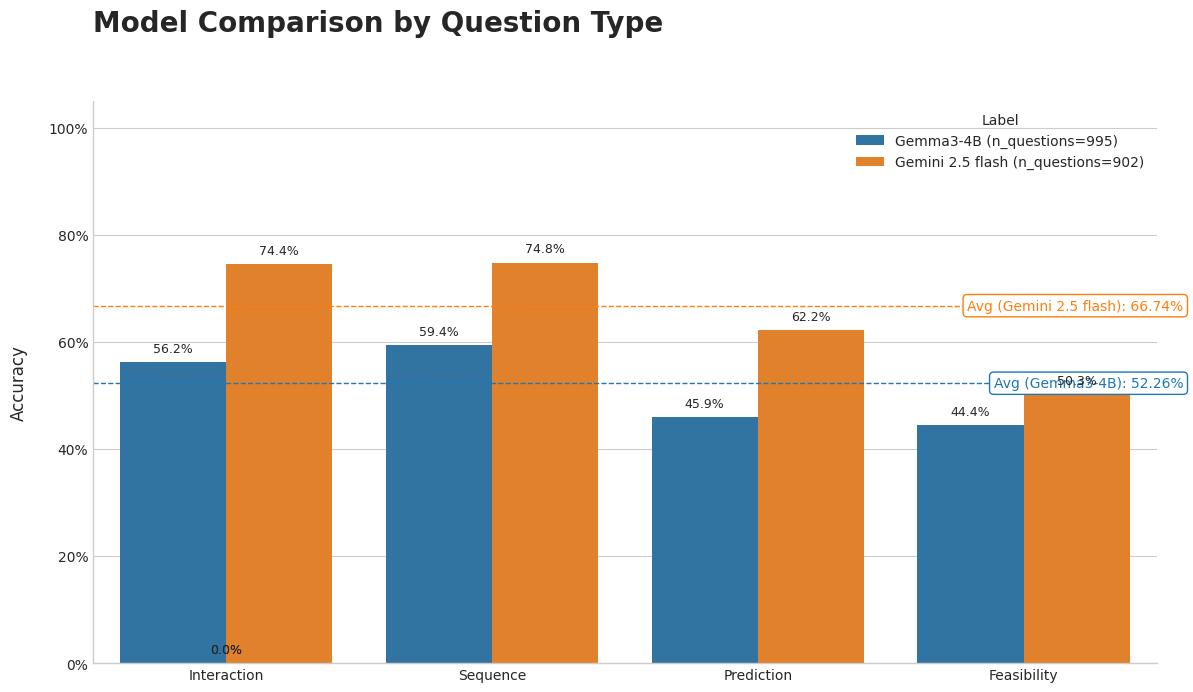

In [ ]:
rp.plot_acc(
    [gemma_eval_df[gemma_eval_df['contains_answer']], gemini_eval_df[gemini_eval_df['contains_answer']]],
    labels=['Gemma3-4B', 'Gemini 2.5 flash'], 
    acc_fn=lambda x: rp.accuracy(x, on_what='text'), )


In [ ]:
gemma12_pred_gg_df = rp.ans_extract(GEMMA12_RESPONSES_FPATH, "gemma3", format="ollama")
gemma12_pred_gg_df.rename(columns={"answer": "pred_text"}, inplace=True)

gemma12_eval_df = gt_df.join(
    gemma12_pred_gg_df,
    how="left"
)

gemma12_eval_df['contains_answer'] = (
    gemma12_eval_df['contains_answer'].fillna(False).astype(bool)
)
gemma12_eval_df['pred_text'] = (
    gemma12_eval_df['pred_text'].fillna("").astype(str)
)

rp.print_acc(gemma12_eval_df[gemma12_eval_df['contains_answer']], acc_fn=lambda x: rp.accuracy(x, on_what="text"))
rp.print_ans_perc(gemma12_eval_df[gemma12_eval_df['contains_answer']], gt_df,)


Total answers: 1033
Answers following JSON template: 1031
Percentage following JSON template: 99.81%
Answer with a valid alternative: 920
89.23% of the total

Invalid answers: 111
Question type       Total      Accuracy 

Interaction          272        64.34%  
Sequence             250        67.20%  
Prediction           202        61.39%  
Feasibility          196        50.00%  

Average              920        61.41%  
Question type       Total      Answered 

Interaction          298        91.28%  
Sequence             291        85.91%  
Prediction           239        84.52%  
Feasibility          220        89.09%  
Overall             1048        87.79%  


/home/lusha/star_code/src/response_processing.py:186: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(
/tmp/ipykernel_465873/872016120.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  gemma12_eval_df['contains_answer'].fillna(False).astype(bool)


Interaction          272        64.34%  
Sequence             250        67.20%  
Prediction           202        61.39%  
Feasibility          196        50.00%  

Average              920        61.41%  

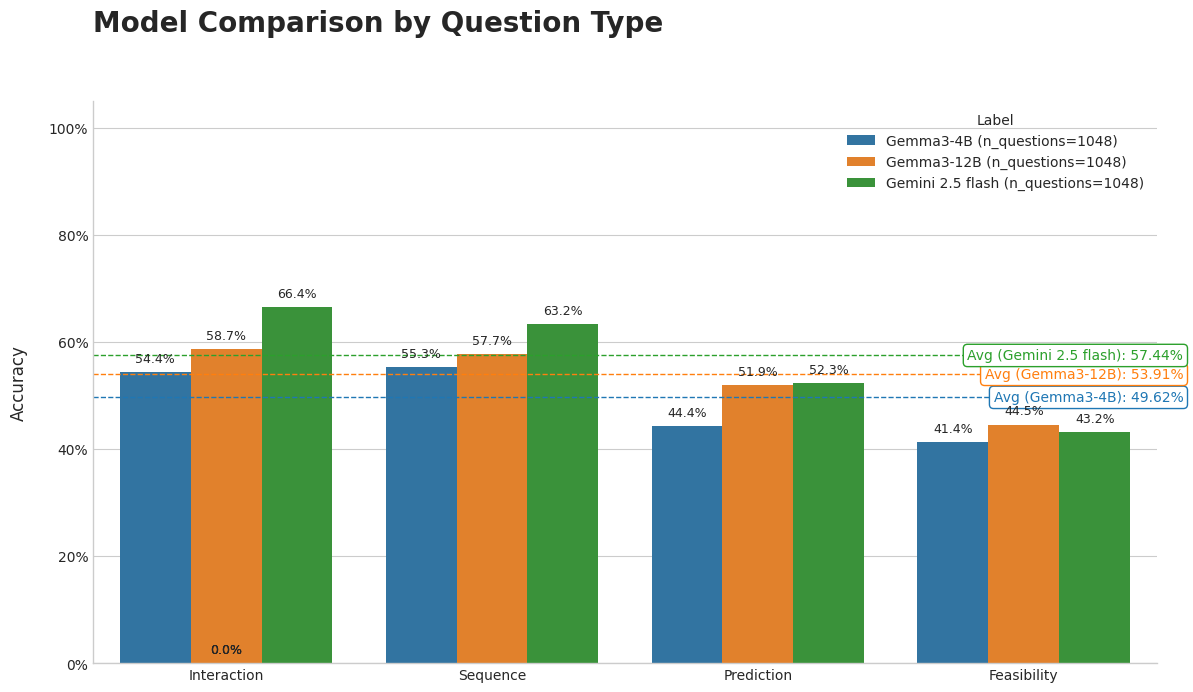

In [ ]:
rp.plot_acc(
    [gemma_eval_df, gemma12_eval_df, gemini_eval_df],
    labels=['Gemma3-4B', 'Gemma3-12B', 'Gemini 2.5 flash'], 
    acc_fn=lambda x: rp.accuracy(x, on_what='text'), )


In [ ]:
importlib.reload(rp)


<module 'src.response_processing' from '/home/lusha/star_code/src/response_processing.py'>

/home/lusha/star_code/src/response_processing.py:613: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)


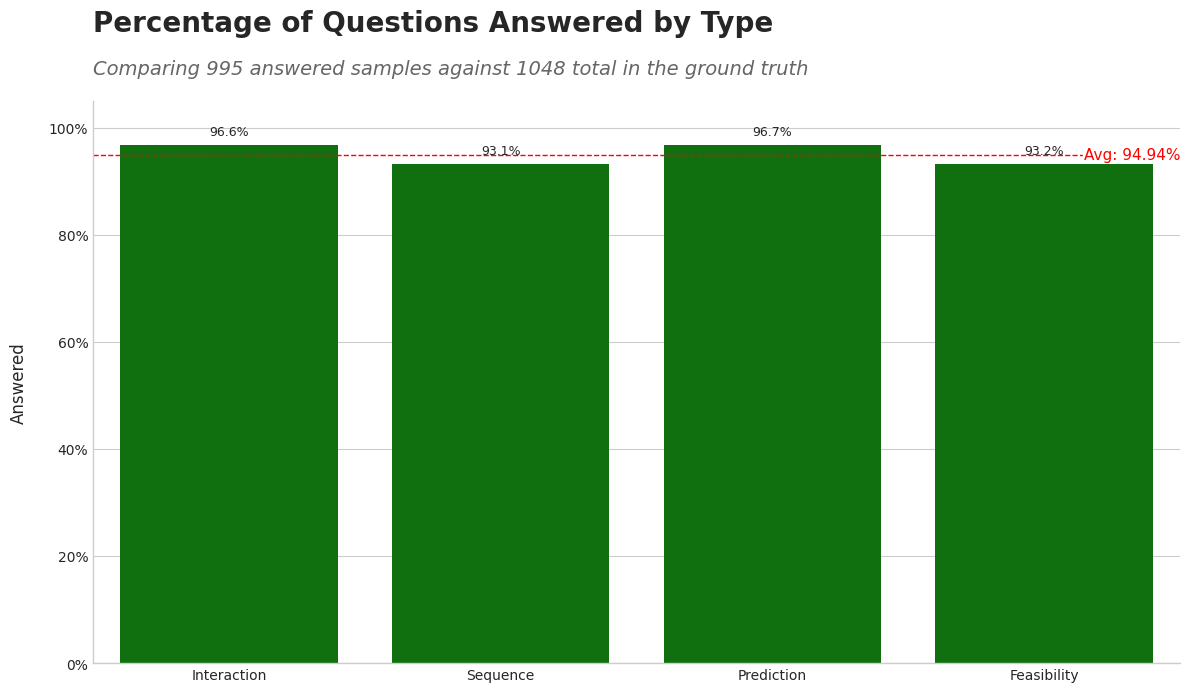

In [ ]:
rp.plot_ans_perc(
    gemma_eval_df[gemma_eval_df['contains_answer']],
    gt_df,
)


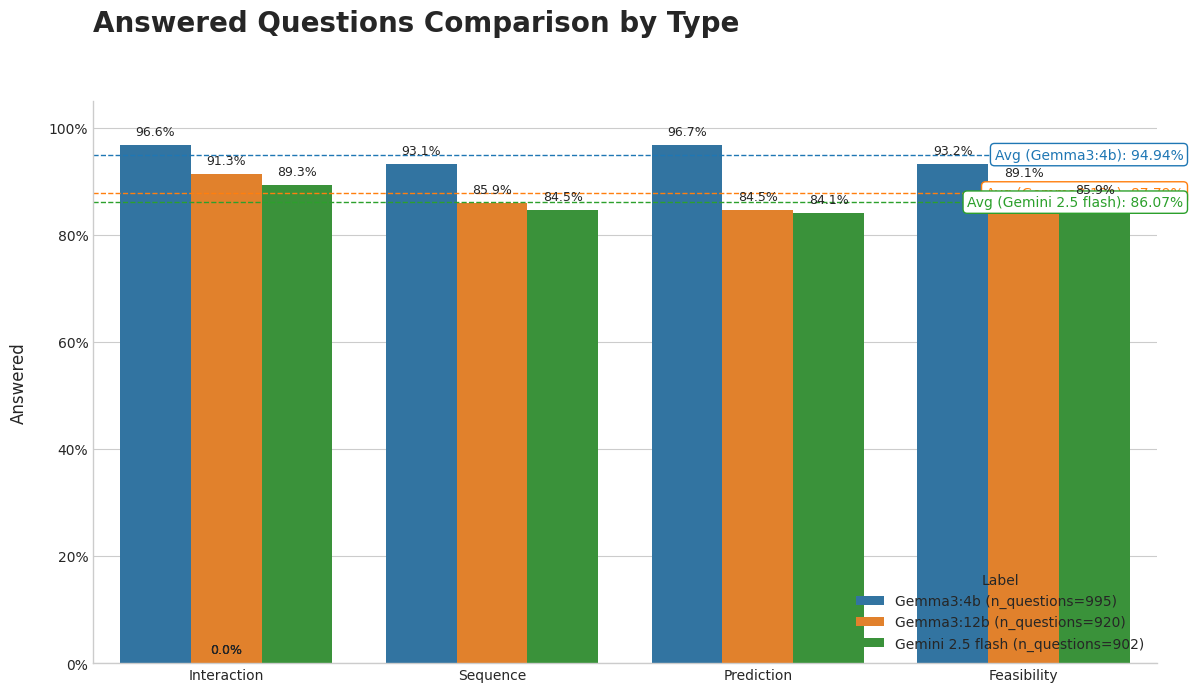

In [ ]:
rp.plot_ans_perc(
    [
        gemma_eval_df[gemma_eval_df['contains_answer']],
        gemma12_eval_df[gemma12_eval_df['contains_answer']],
        gemini_eval_df[gemini_eval_df['contains_answer']]
    ],
    gt_df,
    labels=["Gemma3:4b", "Gemma3:12b", "Gemini 2.5 flash"]
)


In [ ]:
eval_df_all = gt_df.join(
    gemma_pred_gg_df[gemma_pred_gg_df['contains_answer']].rename(columns={'pred_text': 'pred_text1'})[['pred_text1']],
    how='inner'
).join(
    gemini_pred_gg_df[gemini_pred_gg_df['contains_answer']].rename(columns={'pred_text': 'pred_text2'})[['pred_text2']],
    how='inner'
)

eval_df_all['text'] = eval_df_all['text'].str.lower()
eval_df_all['pred_text1'] = eval_df_all['pred_text1'].str.lower()
eval_df_all['pred_text2'] = eval_df_all['pred_text2'].str.lower()
eval_df_all[['question', 'text', 'pred_text1', 'pred_text2']]


,question,text,pred_text1,pred_text2
Feasibility_T5_1851,Which object is the person able to close after...,the laptop.,the laptop.,the book.
Prediction_T2_450,What will the person do next with the clothes?,take.,take.,put down.
Feasibility_T5_1670,Which object is the person able to hold after ...,the dish.,the clothes.,the dish.
Sequence_T5_4571,What did the person do to the clothes after si...,put down.,put down.,put down.
Prediction_T1_499,What will the person do next?,put down the shoe.,sit on the sofa/couch.,put down the bag.
...,...,...,...,...
Interaction_T1_8913,Which object was taken by the person?,the paper/notebook.,the paper/notebook.,the paper/notebook.
Interaction_T1_8967,Which object was taken by the person?,the dish.,the dish.,the food.
Interaction_T2_1847,What did the person do with the paper/notebook?,took.,took.,put down.
Interaction_T2_3423,What did the person do with the bed?,lied on.,sat on.,sat on.


In [ ]:
print(f"Questions answered by both models: \n - {eval_df_all.shape[0]}")


Questions answered by both models: 
 - 874


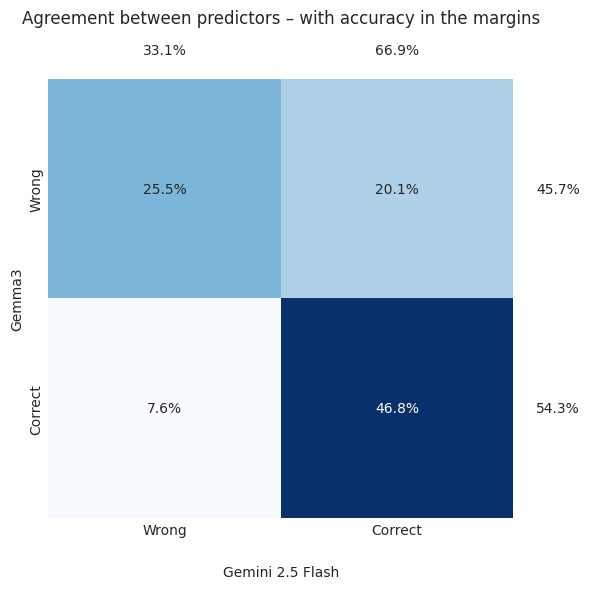

(874, 10)


In [ ]:
display_eval = eval_df_all
pred_vqa_correct = (display_eval['text'] == display_eval['pred_text1']).astype(int).values
pred_gg_correct  = (display_eval['text'] == display_eval['pred_text2']).astype(int).values
labels = ['Wrong', 'Correct']

# confusion matrix (normalized over all)
cm = confusion_matrix(pred_vqa_correct, pred_gg_correct, normalize='all')

# compute marginal sums and convert to % of total
row_totals = cm.sum(axis=1)
col_totals = cm.sum(axis=0)
total = cm.sum()
row_pct = row_totals / total
col_pct = col_totals / total

fig, ax = plt.subplots(figsize=(6, 6))  
sns.heatmap(cm, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar=False, ax=ax)

# annotate row marginals at the right of each row
for i, p in enumerate(row_pct):
    ax.text(len(labels) + 0.1,  i + 0.5, f'{p:.1%}', 
            va='center', ha='left', fontsize=10)

# annotate column marginals just above each column
for j, p in enumerate(col_pct):
    ax.text(j + 0.5, -0.1, f'{p:.1%}', 
            ha='center', va='bottom', fontsize=10)

# move x-axis labels (and xlabel) to the top
ax.set_xlabel('Gemini 2.5 Flash', labelpad=20)
ax.set_ylabel('Gemma3')
ax.set_title('Agreement between predictors – with accuracy in the margins', pad=40)

# make xtick labels horizontal
ax.set_xticklabels(labels, rotation=0)

plt.tight_layout()
plt.show()
print(eval_df_all.shape)


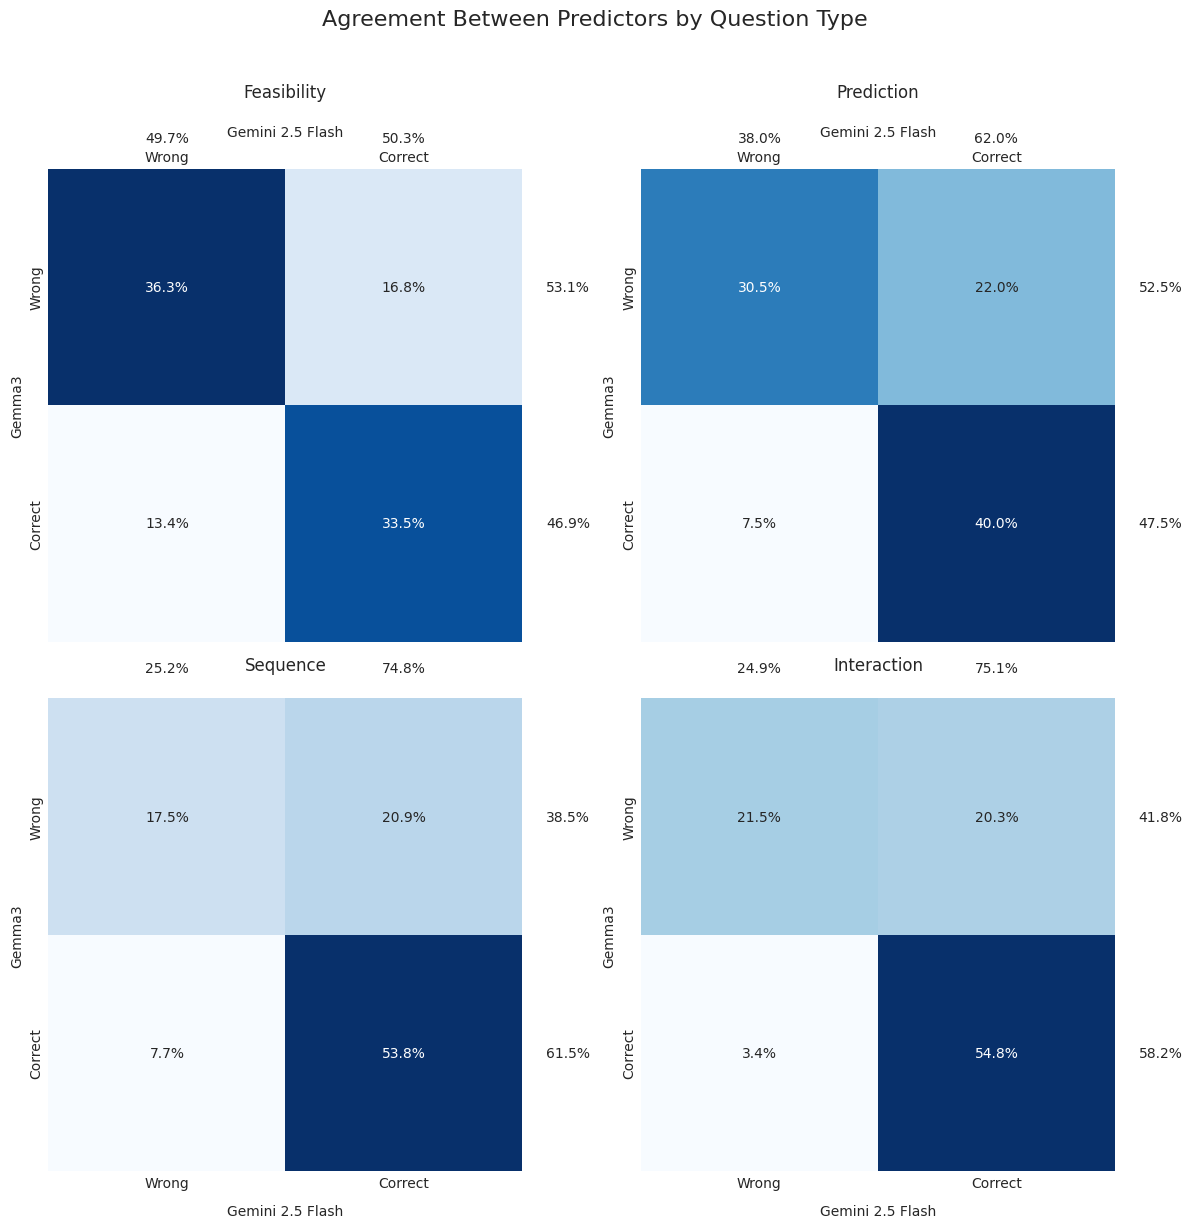

In [ ]:
# Create a copy of the DataFrame for visualization
viz_df = eval_df_all.copy()

# Extract question type from the index
viz_df['question_type'] = viz_df.index.str.split('_').str[0]

# Get unique question types
question_types = viz_df['question_type'].unique()

# Set up the plot grid
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle('Agreement Between Predictors by Question Type', y=1.02, fontsize=16)

# Flatten axes for easy iteration
axes = axes.flatten()

for i, qtype in enumerate(question_types):
    # Filter data for this question type
    subset = viz_df[viz_df['question_type'] == qtype]
    
    # Calculate correctness
    pred_vqa_correct = (subset['text'] == subset['pred_text1']).astype(int).values
    pred_gg_correct = (subset['text'] == subset['pred_text2']).astype(int).values
    
    # Confusion matrix (normalized over all)
    cm = confusion_matrix(pred_vqa_correct, pred_gg_correct, normalize='all')
    
    # Compute marginal sums
    row_totals = cm.sum(axis=1)
    col_totals = cm.sum(axis=0)
    total = cm.sum()
    row_pct = row_totals / total
    col_pct = col_totals / total
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='.1%', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                cbar=False, ax=axes[i])
    
    # Annotate row marginals
    for j, p in enumerate(row_pct):
        axes[i].text(len(labels) + 0.1, j + 0.5, f'{p:.1%}', 
                    va='center', ha='left', fontsize=10)
    
    # Annotate column marginals
    for k, p in enumerate(col_pct):
        axes[i].text(k + 0.5, -0.1, f'{p:.1%}', 
                    ha='center', va='bottom', fontsize=10)
    
    # Customize subplot
    axes[i].set_title(qtype, pad=20)
    axes[i].set_xlabel('Gemini 2.5 Flash', labelpad=10)
    axes[i].set_ylabel('Gemma3')
    axes[i].set_xticklabels(labels, rotation=0)
    
    # Move x-axis to top for all but bottom row
    if i < 2:  # Top row
        axes[i].xaxis.set_ticks_position('top')
        axes[i].xaxis.set_label_position('top')

plt.tight_layout()
plt.show()


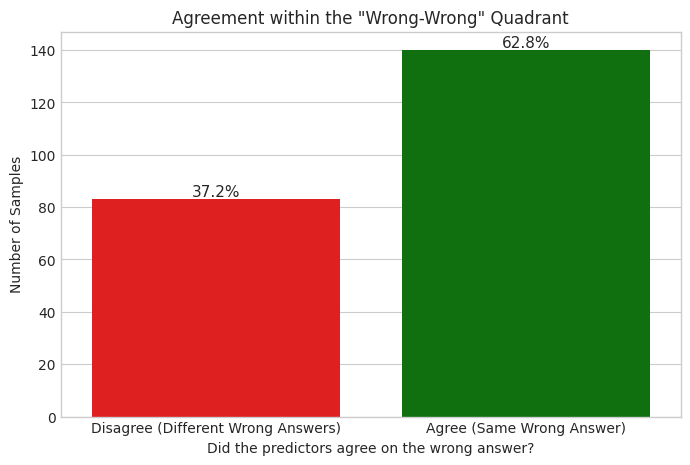

In [ ]:
wrong_wrong_df = eval_df_all[
    (eval_df_all['text'] != eval_df_all['pred_text1']) &
    (eval_df_all['text'] != eval_df_all['pred_text2'])
].copy()

wrong_wrong_df['agreement_on_wrong'] = (
    wrong_wrong_df['pred_text1'] == wrong_wrong_df['pred_text2']
)

# Visualize the result
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=wrong_wrong_df,
    x='agreement_on_wrong',
    hue='agreement_on_wrong',
    palette=['Red', 'Green'],
    legend=False
)

plt.title('Agreement within the "Wrong-Wrong" Quadrant')
plt.ylabel('Number of Samples')
plt.xlabel('Did the predictors agree on the wrong answer?')
ax.set_xticks([0, 1]) 
ax.set_xticklabels(['Disagree (Different Wrong Answers)', 'Agree (Same Wrong Answer)'])

# Add percentage annotations
total = len(wrong_wrong_df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=11)

plt.show()


/tmp/ipykernel_465873/1012052540.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


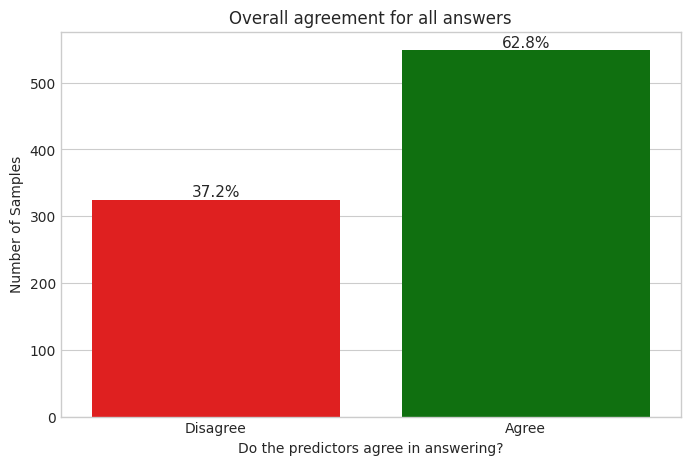

In [ ]:
agreement_df = pd.DataFrame((eval_df_all['pred_text1'] == eval_df_all['pred_text2']), columns=['agreement'])

# Visualize the result
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=agreement_df,
    x='agreement',
    palette=['Red', 'Green']
)

plt.title('Overall agreement for all answers')
plt.ylabel('Number of Samples')
plt.xlabel('Do the predictors agree in answering?')
ax.set_xticks([0, 1]) 
ax.set_xticklabels(['Disagree', 'Agree'])

# Add percentage annotations
total = len(agreement_df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=11)

plt.show()


/tmp/ipykernel_465873/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_465873/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_465873/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_465873/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


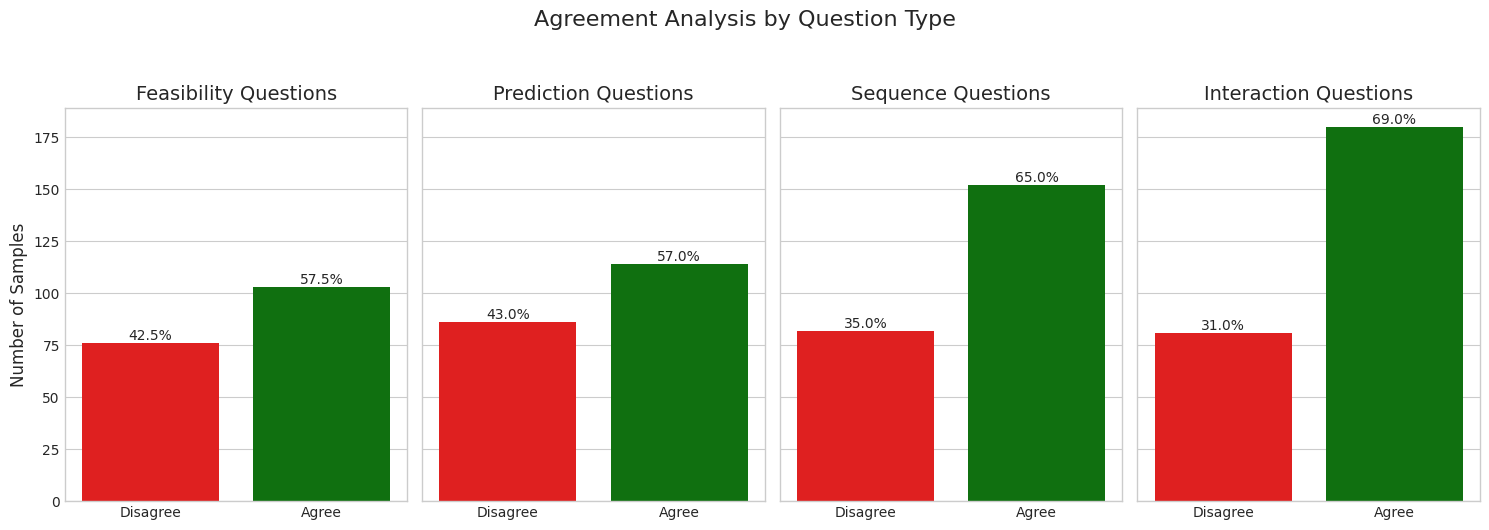

In [ ]:
# Create a copy of the DataFrame for visualization
viz_df = eval_df_all.copy()

# Extract question type from the index
viz_df['question_type'] = viz_df.index.str.split('_').str[0]

# Create agreement column in the copy
viz_df['agreement'] = viz_df['pred_text1'] == viz_df['pred_text2']

# Get unique question types
question_types = viz_df['question_type'].unique()
n_types = len(question_types)

# Create subplots
fig, axes = plt.subplots(1, n_types, figsize=(15, 5), sharey=True)
fig.suptitle('Agreement Analysis by Question Type', fontsize=16, y=1.05)

for i, qtype in enumerate(question_types):
    # Filter data for this question type
    subset = viz_df[viz_df['question_type'] == qtype]
    
    # Create countplot
    ax = sns.countplot(
        data=subset,
        x='agreement',
        palette=['Red', 'Green'],
        ax=axes[i]
    )
    
    # Set title and labels
    ax.set_title(f'{qtype} Questions', fontsize=14)
    ax.set_xlabel('')
    if i == 0:
        ax.set_ylabel('Number of Samples', fontsize=12)
    
    # Set x-ticks
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Disagree', 'Agree'])
    
    # Add percentage annotations
    total = len(subset)
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


## Inspection - 1
Check why Gemini doesn't answer some on the questions

In [ ]:
gemma_pred_gg_df = rp.ans_extract(GEMMA_RESPONSES_FPATH, "gemma3", format="ollama")
gemini_pred_gg_df = rp.ans_extract(GEMINI_RESPONSES_FPATH, "gemma3", format="gemini")


/home/lusha/star_code/src/response_processing.py:187: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(
Error executing eval on: {"answer": "The provided Spatio-Temporal Scene Graph does not contain any information about the person holding food. Therefore, it is not possible to answer what happened after the person held the food based on the given data. None of the alternatives can be confirmed or denied in relation to the premise of \holding food.\"}.


Total answers: 1033
Answers following JSON template: 1033
Percentage following JSON template: 100.00%
Answer with a valid alternative: 995
96.32% of the total

Invalid answers: 38
Total answers: 1033
Answers following JSON template: 1033
Percentage following JSON template: 100.00%
Answer with a valid alternative: 902
87.32% of the total

Invalid answers: 131


/home/lusha/star_code/src/response_processing.py:187: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(


In [ ]:
gemini_unanswered = gemini_pred_gg_df[~gemini_pred_gg_df['contains_answer']]
gemini_unanswered_index = gemini_unanswered.index


## Sample

In [ ]:
SHOW_VIDEO = False
idx = gemini_unanswered_index[9]
idx = "Sequence_T4_1402"


### Text inspection

##### Gemini

In [ ]:
qa_viz.compact_print_qa(idx, gt_df.rename(columns={'text': 'answer'}), [gemini_pred_gg_df.rename(columns={'answer': 'pred_text'})])



┌─ Sample: Sequence_T4_1402 ────────────────────────────────────────────────────────────────
│
│ Question:
│    What happened before the person held the medicine?
│ Alternatives:
│    0. Took the dish.
│    1. Opened the box.
│    2. Threw the box.
│    3. Washed the window.
│
│ Ground Truth:
│    Opened the box.
│
│
│ Model Predictions - Prediction 1:
│    Prediction:
│        Opened the box. [CORRECT]
│    Reasoning:
│        
│        1. **Question Interpretation:** The question asks to identify the action performed by the person immediately before they started holding the "medicine". Based on the context of the STSG, "white_and_blue_carton" appears to be the item being referred to as "medicine" due to the subsequent actions of opening/manipulating it and using a screwdriver on it, implying it's a package for some contents.
│        
│        2. **STSG Analysis:**
│            * **Frame 0-4:** The man is consuming contents from a spoon, holding a cylindrical container.
│           

In [ ]:
print(gemini_pred_gg_df.loc[idx]['chat_history'][0]['content'])



Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
<stsg>
Frame 0:
<scene_graph>
man ---- wearing ---- polo_shirt
man ---- looking_at ---- hands
man ---- holding_in_left_hand ---- spoon
man ---- holding_in_right_hand ---- cylindrical_container
cylindrical_container ---- in_front_of ---- man
bottles_and_containers ---- on_top_of ---- surface
surface ---- to_the_left_of ---- man
</scene_graph>

Frame 1-3:
<scene_graph>
man ---- wearing ---- polo_shirt
man ---- looking_at ---- hands
man ---- holding_in_left_hand ---- spoon
man ---- holding_in_right_hand ---- cylindrical_container
man ---- manipulating ---- contents_in_spoon
man ---- manipulating ---- cylindrical_container
cylindrical_container ---- in_front_of ---- man
bottles_and_containers ---- on_top_of ---- surface
surface ---- to_the_left_of ---- man
</scene_graph>

Frame 4:
<scene_graph>
man ---- wearing ---- polo_shirt
man ---- bringing 

In [ ]:
print(gemini_pred_gg_df.loc[idx]['chat_history'][1]['content'])



1. **Question Interpretation:** The question asks to identify the action performed by the person immediately before they started holding the "medicine". Based on the context of the STSG, "white_and_blue_carton" appears to be the item being referred to as "medicine" due to the subsequent actions of opening/manipulating it and using a screwdriver on it, implying it's a package for some contents.

2. **STSG Analysis:**
    * **Frame 0-4:** The man is consuming contents from a spoon, holding a cylindrical container.
    * **Frame 5:** The man lowers his left hand and looks at items on a surface, specifically a "white_and_blue_carton".
    * **Frame 6:** The man extends his left hand and reaches for the "white_and_blue_carton".
    * **Frame 7-11:** The man picks up the "white_and_blue_carton" and holds it in both hands, then "opening_or_manipulating" it. This is the point where he starts holding the "medicine" (white_and_blue_carton).

3. **Alternative Evaluation:**
    *   **A. Took the 

In [ ]:
print(gemini_pred_gg_df.loc[idx]['chat_history'][3]['content'])



```json
{"answer": "B. Opened the box."}
```


#### Gemma

In [ ]:
idx


'Sequence_T4_1402'

In [ ]:
qa_viz.compact_print_qa(idx, gt_df.rename(columns={'text': 'answer'}), [gemma_pred_gg_df.rename(columns={'answer': 'pred_text'})])



┌─ Sample: Sequence_T4_1402 ────────────────────────────────────────────────────────────────
│
│ Question:
│    What happened before the person held the medicine?
│ Alternatives:
│    0. Took the dish.
│    1. Opened the box.
│    2. Threw the box.
│    3. Washed the window.
│
│ Ground Truth:
│    Opened the box.
│
│
│ Model Predictions - Prediction 1:
│    Prediction:
│        Opened the box. [CORRECT]
│    Reasoning:
│        Okay, let's analyze the scene graph to answer the question: "What happened before the person held the medicine?" (referring to the white and blue carton, which we assume contains the medicine).
│        
│        1. **Question Interpretation:** The question asks for the sequence of events leading up to the person holding the white and blue carton. We need to identify what actions occurred *before* the final frame where the person is explicitly holding the carton.
│        
│        2. **STSG Analysis:**
│           * **Frames 0-3:** The man is initially holding

In [ ]:
print(gemma_pred_gg_df.loc[idx]['chat_history'][0]['content'])


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
<stsg>
Frame 0:
<scene_graph>
man ---- wearing ---- polo_shirt
man ---- looking_at ---- hands
man ---- holding_in_left_hand ---- spoon
man ---- holding_in_right_hand ---- cylindrical_container
cylindrical_container ---- in_front_of ---- man
bottles_and_containers ---- on_top_of ---- surface
surface ---- to_the_left_of ---- man
</scene_graph>

Frame 1-3:
<scene_graph>
man ---- wearing ---- polo_shirt
man ---- looking_at ---- hands
man ---- holding_in_left_hand ---- spoon
man ---- holding_in_right_hand ---- cylindrical_container
man ---- manipulating ---- contents_in_spoon
man ---- manipulating ---- cylindrical_container
cylindrical_container ---- in_front_of ---- man
bottles_and_containers ---- on_top_of ---- surface
surface ---- to_the_left_of ---- man
</scene_graph>

Frame 4:
<scene_graph>
man ---- wearing ---- polo_shirt
man ---- bringing -

In [ ]:
print(gemma_pred_gg_df.loc[idx]['chat_history'][1]['content'])


Okay, let's analyze the scene graph to answer the question: "What happened before the person held the medicine?" (referring to the white and blue carton, which we assume contains the medicine).

1. **Question Interpretation:** The question asks for the sequence of events leading up to the person holding the white and blue carton. We need to identify what actions occurred *before* the final frame where the person is explicitly holding the carton.

2. **STSG Analysis:**
   * **Frames 0-3:** The man is initially holding a spoon and a cylindrical container. He’s manipulating the contents of the spoon and the container. This establishes the initial setup.
   * **Frame 4:** The man *brings the spoon to his mouth* and *consumes contents from the spoon*. This is a key moment – he’s actively using something from the carton (presumably the medicine).
   * **Frames 5-7:** The man is lowering his left hand and looking at items on the surface. He then reaches for the white and blue carton.
   * **F

In [ ]:
print(gemma_pred_gg_df.loc[idx]['chat_history'][3]['content'])


```json
{"answer": "B. Opened the box."}
```


### Visual Inspection

#### Inspect frames

In [ ]:
import math

frames_per_row = 6

if SHOW_VIDEO:
    video_path = RAW_VIDEO_DIR / f"{gt_df.loc[idx]['video_id']}.mp4"
    start = gt_df.loc[idx]['start']
    end = gt_df.loc[idx]['end']
    # values used in the experiments
    fps = 1
    max_frames = 64

    frame_dir, frame_paths = video_tools.extract_frames(
        video_path,
        fps=fps,
        max_frames=max_frames,
        start_time=start,
        end_time=end,
    )
    
    frames_per_row = min(frames_per_row, len(frame_paths))
    rows = math.ceil(len(frame_paths) / frames_per_row)
    
    images = frame_paths
    fig, axes = plt.subplots(rows, frames_per_row, figsize=(18, 4))
    axes = axes.flatten()
    
    for i, img_path in enumerate(images):
        img = mpimg.imread(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f"{i+1}")
        axes[i].axis('off')
    
    # Turn off the axes for any remaining subplots
    for i in range(len(images), len(axes)):
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()


#### Inspect the video

In [ ]:
if SHOW_VIDEO:
    videoviz.Vis_Video(
        {"question_id": idx, **gt_df.loc[idx].to_dict()},
        RAW_VIDEO_DIR,
        SAVE_VIDEO_DIR)
